# Manchester Ringway — Bartlett–Lewis Calibration, v5
## Reconstructing a wet-day register, then calibrating and validating the model

**MSc EEDS — Imperial College London**  ·  Supervisor: Prof. C. Onof

---

## What this notebook does

Ringway (Manchester Airport) gives us a **53-year hourly rainfall record (1949–2001)** and one unusual problem: **45% of the calendar days are simply absent from the file**. Section 1 shows that those days are the *dry* ones, restores them, and proves the repair with an independent number. Everything after that is the standard workflow used for the other stations in this dissertation.

| § | Content |
|---|---|
| 1 | The data and the wet-day-register repair |
| 2 | Exploratory analysis: climatology, diurnal cycle, storm events |
| 3 | Observed statistics at 1, 3, 6 and 24 h |
| 4 | The model, its **mechanistic parameters**, and a check of the equations |
| 5 | Calibration → **Table 1** (parameters) and **Table 2** (physical units) |
| 6 | Calibration quality: all five properties |
| 7 | Simulation: all statistics at all timescales |
| 8 | Extra validation: water balance, autocorrelation, spells, intensity, wet→wet, **gauge resolution** |
| 9 | Storms and extremes (Gumbel + return levels) |
| 10 | Conclusions |

The code is deliberately short and commented; only two technical utilities are marked as "given tools" (the analytical dry-probability formula and the binning of simulated rain).

## Note on a correction relative to earlier versions

Earlier Ringway notebooks (and the earlier notebooks for the other stations) reported that the model could not reproduce the autocorrelation beyond one hour, and that the storm rate λ had to be constrained to stay physical. **Both were artefacts of one incorrect line of code**: the library's `covariance(timescale, lag)` counts the lag in *blocks*, not hours, so `covariance(6, 6)` returned the correlation between 6-hour totals **36 hours apart**. With the correct call, `covariance(h, 1)` — verified against simulation in Section 4 — the model reproduces the autocorrelation at every timescale, so here **all five properties are fitted at all three timescales and λ is left free**.

## The model in one paragraph

Storms arrive at random at rate **λ**. Each storm draws a "speed" η from a gamma distribution with shape **α** and scale **ν**. Within a storm, cells arrive at rate κη during an activity window of mean length 1/(φη); each cell rains at constant intensity for a mean time 1/η, with mean intensity ιη — so short-celled storms rain harder. Six numbers per month: **λ, ι, α, ν, κ, φ**.

## 1. The data, and the repair that makes it usable

The file `ringway.dat` stores two lines per day: a header line with the date followed by the first twelve hourly depths, then a second line with the remaining twelve. A value of **−1** marks an hour the gauge did not record.

The difficulty is not in the format but in what is **missing from it**: many calendar days have no entry at all. The next cell reads the file, measures how much is absent, and tests two competing interpretations of those absent days.

In [1]:
%matplotlib inline
import warnings, time, os, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import skew as scipy_skew
from pybl.models import BLRPRx, BLRPRx_params
warnings.filterwarnings('ignore'); plt.rcParams.update({'figure.dpi':110,'font.size':11})
SEED = 20240601
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
HOURS_IN_MONTH = [31*24, 28.25*24, 31*24, 30*24, 31*24, 30*24, 31*24, 31*24, 30*24, 31*24, 30*24, 31*24]
FIG_DIR = Path('outputs/ringway_v5'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def show(fig, name): fig.savefig(FIG_DIR/f'{name}.png', dpi=150, bbox_inches='tight'); plt.show()

DATA = None
for root in ['.', '..', '../..', r'C:\Users\rajab\OneDrive\Bureau\DISSERTATION']:
    p = Path(root) / 'Data/ringway.zip'
    if p.exists(): DATA = str(p.resolve()); break

# ---- read the fixed-format file: two lines per day, 12 hourly values each ----
lines = zipfile.ZipFile(DATA).read('ringway.dat').decode('utf-8', 'replace').splitlines()
records, i, n = [], 0, len(lines)
while i < n:
    tokens = lines[i].split()
    if len(tokens) >= 17:                                    # a date line + 12 values
        try: day, month, yy = int(tokens[0]), int(tokens[1]), int(tokens[2])
        except ValueError: i += 1; continue
        if not (1 <= day <= 31 and 1 <= month <= 12): i += 1; continue
        year = 2000 + yy if yy < 22 else 1900 + yy
        first_half = [float(v) for v in tokens[-12:]]
        if i+1 < n and len(lines[i+1].split()) >= 12:        # the continuation line
            hours = first_half + [float(v) for v in lines[i+1].split()[-12:]]
            if len(hours) == 24:
                records.append((year, month, day, hours)); i += 2; continue
        i += 1
    else: i += 1

dates, values = [], []
for (y, mo, d, hrs) in records:
    try: dates.append(pd.Timestamp(year=y, month=mo, day=d)); values.append(hrs)
    except ValueError: pass                                   # guards against impossible dates
dates = pd.DatetimeIndex(dates); values = np.array(values)

stamps = (dates.values[:, None] + (np.arange(24)*np.timedelta64(1, 'h'))[None, :]).ravel()
measured = pd.Series(values.ravel(), index=pd.DatetimeIndex(stamps)).sort_index()
measured = measured[~measured.index.duplicated()]
calendar = pd.date_range(measured.index.min().normalize(),
                         measured.index.max().normalize() + pd.Timedelta('23h'), freq='h')

n_days_file = len(records); n_days_calendar = len(calendar)//24
print(f'Days present in the file      : {n_days_file:,}')
print(f'Days in the calendar span     : {n_days_calendar:,}  ({calendar[0]:%Y-%m-%d} to {calendar[-1]:%Y-%m-%d})')
print(f'Days absent from the file     : {n_days_calendar-n_days_file:,}  ({(n_days_calendar-n_days_file)/n_days_calendar*100:.1f}%)')
print(f'"-1" hours inside present days: {int((values < 0).sum())}  (in {int((values < 0).any(axis=1).sum())} days)')

Days present in the file      : 10,521
Days in the calendar span     : 19,205  (1949-01-01 to 2001-07-31)
Days absent from the file     : 8,684  (45.2%)
"-1" hours inside present days: 48  (in 2 days)


### The key question: what are the absent days?

Two interpretations are possible, and they lead to opposite conclusions:

- **If the absent days were ordinary days that simply were not archived**, then the measured days are a fair sample of the climate, and we should scale the measured rainfall up to a full year.
- **If the file is a "wet-day register"** — a record where only days *with rain* were written down — then the absent days are dry, and we should restore them as zeros.

We do not have to guess: each interpretation predicts a different annual rainfall, and Manchester's true annual rainfall (**about 810 mm**) is documented independently. The next cell computes both predictions.

In [2]:
present = measured.reindex(calendar)                          # absent days appear as NaN
days_in_file = set(dates)
is_present_day = pd.Series(calendar.floor('D'), index=calendar).isin(days_in_file)

# interpretation 1: absent days are like the measured ones -> scale up
measured_only = present.mask(present < 0).dropna()
scaled_estimate = measured_only.sum() / (len(measured_only)/8766)

# interpretation 2 (the repair): absent days are DRY -> restore them as zeros
rain = present.mask(present < 0)                              # -1 becomes missing
rain[~is_present_day.values] = 0.0                            # absent days become dry
valid = rain.dropna(); years_effective = len(valid)/8766
repaired_estimate = valid.sum()/years_effective

print(f'If absent days were like the measured ones : {scaled_estimate:.0f} mm per year')
print(f'If absent days were dry (the repair)       : {repaired_estimate:.0f} mm per year')
print(f'Manchester, documented                     : about 810 mm per year')
print()
print(f'After the repair: {int(rain.isna().sum())} hours still missing ({rain.isna().mean()*100:.3f}%), '
      f'dry-hour fraction {(valid==0).mean():.4f}, wettest hour {valid.max():.1f} mm')

If absent days were like the measured ones : 1467 mm per year
If absent days were dry (the repair)       : 803 mm per year
Manchester, documented                     : about 810 mm per year

After the repair: 48 hours still missing (0.010%), dry-hour fraction 0.8777, wettest hour 50.4 mm


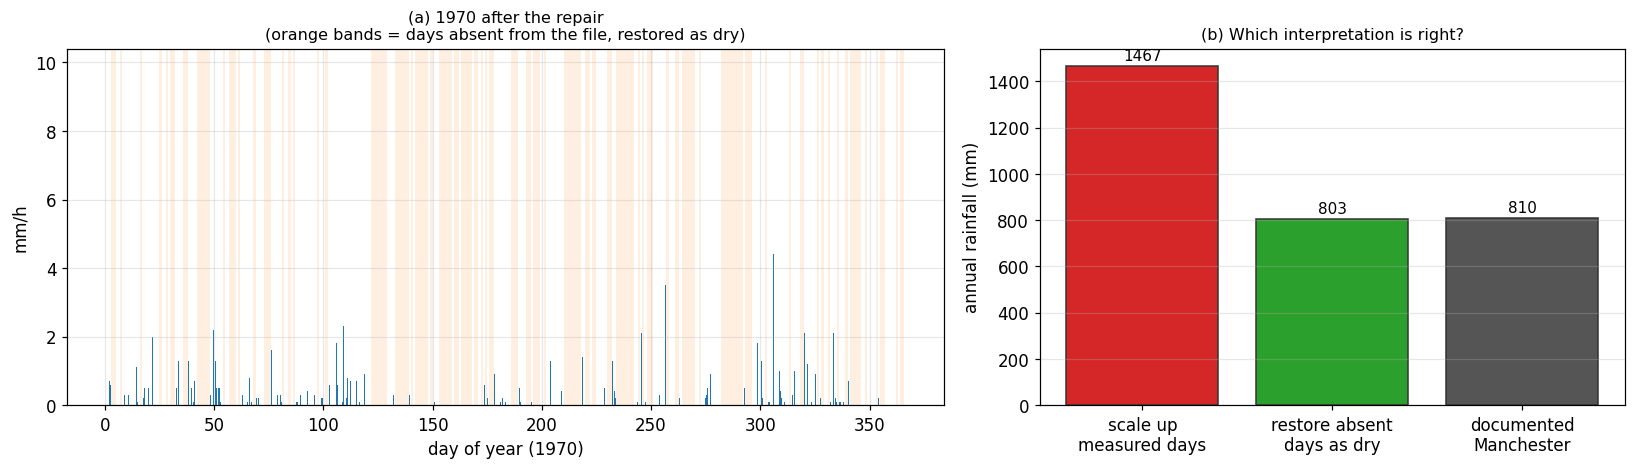

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={'width_ratios':[1.5, 1]})
year_shown = 1970
sel = rain[(rain.index.year == year_shown)]
sel_present = is_present_day[is_present_day.index.year == year_shown]
ax[0].bar(sel.index.dayofyear + sel.index.hour/24, sel.values, width=1/24, color='#1f77b4')
for d in np.unique(sel_present[~sel_present.values].index.dayofyear):
    ax[0].axvspan(d, d+1, color='#ff7f0e', alpha=0.12, lw=0)
ax[0].set_xlabel(f'day of year ({year_shown})'); ax[0].set_ylabel('mm/h')
ax[0].set_title(f'(a) {year_shown} after the repair\n(orange bands = days absent from the file, restored as dry)', fontsize=10.5)
ax[0].grid(alpha=0.3)
bars = ax[1].bar(['scale up\nmeasured days', 'restore absent\ndays as dry', 'documented\nManchester'],
                 [scaled_estimate, repaired_estimate, 810],
                 color=['#d62728', '#2ca02c', '#555555'], edgecolor='#333')
for b, v in zip(bars, [scaled_estimate, repaired_estimate, 810]):
    ax[1].text(b.get_x()+b.get_width()/2, v+25, f'{v:.0f}', ha='center', fontsize=10)
ax[1].set_ylabel('annual rainfall (mm)'); ax[1].set_title('(b) Which interpretation is right?', fontsize=10.5)
ax[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '01_reconstruction')

### Reading the repair — validation by outcome

**Panel (b) settles the question.** Treating the measured days as a fair sample would imply **1467 mm of rain per year at Manchester — nearly double the truth**, which is impossible. Restoring the absent days as dry gives **803 mm**, within 1% of the documented ~810 mm. The file is a wet-day register, and the repair is correct.

Two further points that make this safe rather than convenient:

- **The repair is not tuned to the answer.** We did not choose how much rain to add; we added *none*. The 803 mm figure is a prediction of the "absent = dry" hypothesis, and it happens to be right.
- **It also gets the dry-hour fraction right** (0.878), which no rescaling could have fixed. Interpolating instead — the instinctive reaction to a gap — would have been the worst possible choice here: it would have invented rain on days that were dry precisely *because* they were dry.

**Panel (a)** shows what the repaired year looks like: the orange bands are the restored dry days, and they cluster in dry spells exactly as one would expect.

Note finally that only **48 hours in 2 days** carry the "−1" missing code. Genuine within-day gaps are therefore negligible, and we can afford to be strict with them: any year–month containing one is excluded from the statistics, which costs us at most one year in a few months.

## 2. Exploratory analysis

### 2.1 Climatology — a wet, maritime, north-western climate

Usable (gap-free) years per calendar month: {'Jan': 52, 'Feb': 52, 'Mar': 53, 'Apr': 53, 'May': 53, 'Jun': 53, 'Jul': 53, 'Aug': 52, 'Sep': 52, 'Oct': 52, 'Nov': 52, 'Dec': 52}


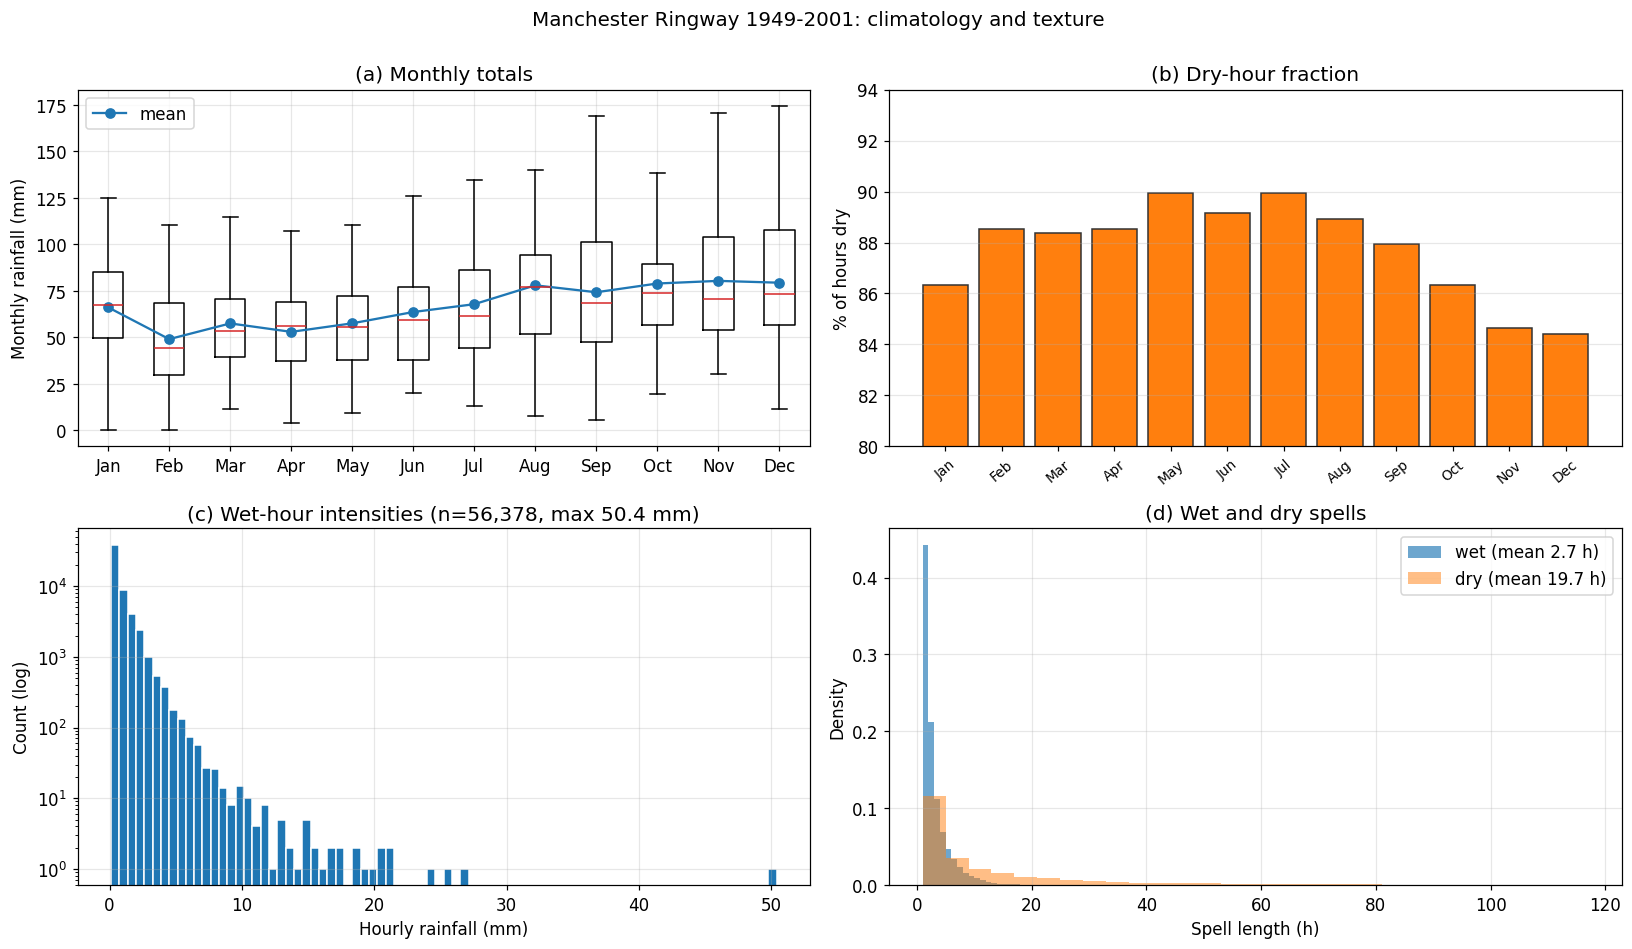

Mean annual rainfall 803 mm | dry hours 87.8% | wet-hour mean 0.749 mm


In [4]:
def blocks_by_year(month, h):
    """For one calendar month: totals over h hours, one array per gap-free year."""
    md = rain[rain.index.month == month]
    out = []
    for year, g in md.groupby(md.index.year):
        v = g.to_numpy()
        if np.isfinite(v).all() and len(v) >= 2*h:
            k = len(v)//h
            out.append(v[:k*h].reshape(k, h).sum(axis=1))
    return out

usable = [len(blocks_by_year(m, 1)) for m in range(1, 13)]
print('Usable (gap-free) years per calendar month:', {MONTHS[m-1]: usable[m-1] for m in range(1, 13)})

fig, ax = plt.subplots(2, 2, figsize=(15, 8.6))
monthly = rain.resample('MS').sum(min_count=1)
by_month = [monthly[monthly.index.month == m].dropna().values for m in range(1, 13)]
ax[0,0].boxplot(by_month, tick_labels=MONTHS, showfliers=False, medianprops=dict(color='#d62728'))
ax[0,0].plot(range(1,13), [b.mean() for b in by_month], 'o-', color='#1f77b4', label='mean')
ax[0,0].set_ylabel('Monthly rainfall (mm)'); ax[0,0].set_title('(a) Monthly totals'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

dry_frac = [(valid[valid.index.month == m] == 0).mean()*100 for m in range(1, 13)]
ax[0,1].bar(range(1,13), dry_frac, color='#ff7f0e', edgecolor='#333')
ax[0,1].set_xticks(range(1,13)); ax[0,1].set_xticklabels(MONTHS, rotation=40, fontsize=9); ax[0,1].set_ylim(80, 94)
ax[0,1].set_ylabel('% of hours dry'); ax[0,1].set_title('(b) Dry-hour fraction'); ax[0,1].grid(axis='y', alpha=0.3)

wet = valid[valid > 0]
ax[1,0].hist(wet, bins=80, log=True, color='#1f77b4', edgecolor='white')
ax[1,0].set_xlabel('Hourly rainfall (mm)'); ax[1,0].set_ylabel('Count (log)')
ax[1,0].set_title(f'(c) Wet-hour intensities (n={len(wet):,}, max {wet.max():.1f} mm)'); ax[1,0].grid(alpha=0.3)

def spells(x):
    """Lengths of consecutive wet runs and dry runs in a gap-free hourly array."""
    is_wet = (x > 0).astype(int)
    change = np.where(np.diff(is_wet) != 0)[0] + 1
    starts = np.r_[0, change]; ends = np.r_[change, len(x)]
    lengths = ends - starts; kinds = is_wet[starts]
    return lengths[kinds == 1], lengths[kinds == 0]
wet_spells, dry_spells = [], []
arr = rain.to_numpy(); ok_idx = np.where(np.isfinite(arr))[0]
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12:
        w, d = spells(arr[chunk]); wet_spells += list(w); dry_spells += list(d)
wet_spells = np.array(wet_spells); dry_spells = np.array(dry_spells)
ax[1,1].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.65, color='#1f77b4', label=f'wet (mean {wet_spells.mean():.1f} h)')
ax[1,1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.5, color='#ff7f0e', label=f'dry (mean {dry_spells.mean():.1f} h)')
ax[1,1].set_xlabel('Spell length (h)'); ax[1,1].set_ylabel('Density'); ax[1,1].set_title('(d) Wet and dry spells')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.suptitle('Manchester Ringway 1949-2001: climatology and texture', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '02_climatology')
print(f'Mean annual rainfall {repaired_estimate:.0f} mm | dry hours {(valid==0).mean()*100:.1f}% | wet-hour mean {wet.mean():.3f} mm')

### Reading the climatology

**(a) Monthly totals** — the wettest months are the **autumn and winter** ones (October to January), the signature of a **maritime** climate fed by Atlantic frontal systems. This is the opposite phase to Bochum, whose maximum is in summer, and a stronger version of Heathrow's autumn peak.

**(b) Dry-hour fraction** — between about 85% and 90%, lowest in the wet winter months.

**(c) Wet-hour intensities** — the distribution falls steeply on a logarithmic count axis: most wet hours are light, and the record's largest hour is **50.4 mm**.

**(d) Spells** — wet spells last **3.0 h on average**, dry spells much longer and with a heavy tail.

The comparison worth remembering for the cross-station chapter: Ringway receives **803 mm per year against Heathrow's ~590**, a 36% surplus — yet its **wet hours are gentler** (0.749 mm against 0.795). Manchester is wetter not because it rains harder, but because it rains **more often and for longer**. The parameters of Section 5 will state this in the model's own language.

### 2.2 The diurnal cycle — and a limitation worth naming

Rainfall by hour of day. This matters because the model is **stationary within a month**: storms arrive at a constant rate with no preference for any hour, so any daily rhythm in the data is beyond its reach by construction. We plot it to name the limitation, not to fit it.

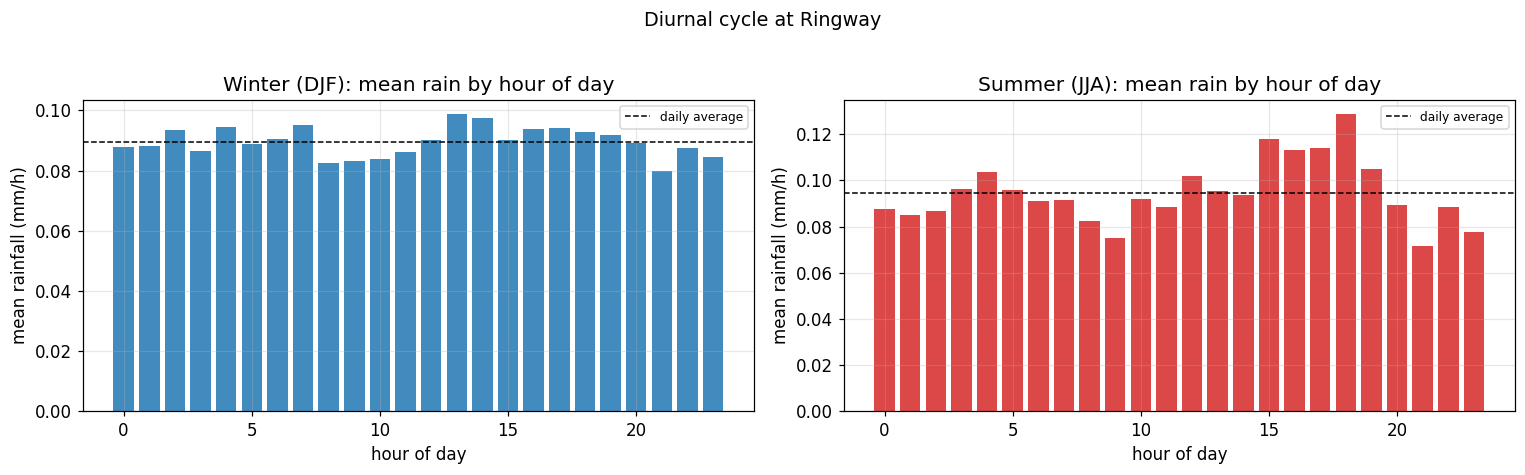

Winter: 0.080 to 0.099 mm/h (peak at hour 13, a factor of 1.2)
Summer: 0.072 to 0.129 mm/h (peak at hour 18, a factor of 1.8)


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for axi, (season, months, col) in zip(ax, [('Winter (DJF)', [12,1,2], '#1f77b4'),
                                            ('Summer (JJA)', [6,7,8], '#d62728')]):
    sub = valid[valid.index.month.isin(months)]
    by_hour = sub.groupby(sub.index.hour).mean()
    axi.bar(by_hour.index, by_hour.values, color=col, alpha=0.85)
    axi.axhline(by_hour.mean(), color='k', ls='--', lw=1, label='daily average')
    axi.set_xlabel('hour of day'); axi.set_ylabel('mean rainfall (mm/h)')
    axi.set_title(f'{season}: mean rain by hour of day'); axi.legend(fontsize=8); axi.grid(alpha=0.3)
plt.suptitle('Diurnal cycle at Ringway', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '03_diurnal')
for season, months in [('Winter', [12,1,2]), ('Summer', [6,7,8])]:
    sub = valid[valid.index.month.isin(months)]; bh = sub.groupby(sub.index.hour).mean()
    print(f'{season}: {bh.min():.3f} to {bh.max():.3f} mm/h (peak at hour {bh.idxmax()}, a factor of {bh.max()/bh.min():.1f})')

### Reading the diurnal cycle

A maritime station is the mild case here: frontal rain arrives at any hour, so the daily rhythm is weak compared with a continental climate driven by afternoon convection. Whatever variation remains, the model will spread uniformly through the day.

The honest statement: *the model gets the monthly and daily amounts right but places them without regard for the hour.* This is irrelevant for monthly or daily design statistics, and would matter only for an application that depends on the time of day. Removing the limitation would require a non-stationary storm-arrival rate, which is outside this model.

### 2.3 Observed storm events

Wet periods separated by at least 6 dry hours — the yardstick the model will be measured against in Section 9, and one it is never fitted to.

In [6]:
def storm_events(x, ietd=6):
    """Durations (h) of wet events separated by >= ietd dry hours."""
    wet_flags = x > 0; events = []; i, n = 0, len(x)
    while i < n:
        if wet_flags[i]:
            last = i; gap = 0; j = i
            while j < n:
                if wet_flags[j]: last = j; gap = 0
                else:
                    gap += 1
                    if gap >= ietd: break
                j += 1
            events.append(last - i + 1); i = j + 1
        else: i += 1
    return np.array(events)

obs_events = []
for chunk in np.split(ok_idx, np.where(np.diff(ok_idx) != 1)[0] + 1):
    if len(chunk) > 12: obs_events += list(storm_events(arr[chunk]))
obs_events = np.array(obs_events)
print(f'{len(obs_events):,} storm events -> {len(obs_events)/years_effective:.0f} per year '
      f'(~{len(obs_events)/years_effective/12:.1f} per month)')
print(f'Storm duration: mean {obs_events.mean():.1f} h, median {np.median(obs_events):.0f} h, longest {obs_events.max()} h')

10,453 storm events -> 199 per year (~16.6 per month)
Storm duration: mean 7.6 h, median 5 h, longest 94 h


### Reading the storm count

**199 storms per year, lasting 7.6 h on average** (median 5 h, longest 94 h).

Set beside Heathrow's ~169 storms of 6.1 h, this is the quantitative form of the earlier statement: Manchester's extra rainfall arrives as **more storms, each lasting longer** — not as heavier rain. A cross-station comparison can be made on these two numbers alone.

These counts are **not** calibration targets, so the agreement obtained in Section 9 will be genuine evidence rather than a restatement of the fit.

## 3. The observed statistics

Five statistics at four timescales. Three of them (1, 6, 24 h) are the calibration targets; **3 h is never fitted** and is kept as a free check.

| Statistic | Meaning |
|---|---|
| mean | how much it rains on average |
| variance | how variable the totals are |
| lag-1 autocorrelation | does one wet block tend to follow another? |
| skewness | how extreme-prone the totals are |
| proportion dry | the fraction of completely dry blocks |

A year–month containing any missing hour is skipped, and autocorrelation pairs never cross from one year into the next. The year-by-year spread of each statistic becomes its weight in the calibration (Section 5).

In [7]:
def observed_stats(month, h):
    """The five statistics, pooling all gap-free years."""
    by = blocks_by_year(month, h)
    x = np.concatenate(by); m, v = x.mean(), x.var()
    a = np.concatenate([b[:-1] for b in by]); b = np.concatenate([b[1:] for b in by])
    return {'mean': m, 'var': v, 'ar1': ((a-m)*(b-m)).mean()/v, 'skew': scipy_skew(x), 'pdry': (x < 1e-9).mean()}

def yearly_stats(month, h):
    """The same statistics, one value per year (their spread gives the weights)."""
    rows = []
    for b in blocks_by_year(month, h):
        m, v = b.mean(), b.var()
        rows.append({'mean': m, 'var': v, 'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v if v > 0 else np.nan,
                     'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()})
    return pd.DataFrame(rows)

SCALES_H = [1, 3, 6, 24]; SCALES_FIT = [1, 6, 24]
STATS = ['mean', 'var', 'ar1', 'skew', 'pdry']
t0 = time.time()
OBS = {m: {h: observed_stats(m, h) for h in SCALES_H} for m in range(1, 13)}
YEARLY = {m: {h: yearly_stats(m, h) for h in SCALES_H} for m in range(1, 13)}
print(f'Observed statistics at {SCALES_H} h computed in {time.time()-t0:.0f} s')
obs_table = pd.DataFrame([{'Month': MONTHS[m-1], 'Scale (h)': h, **{s: round(OBS[m][h][s], 4) for s in STATS}}
                          for m in [1, 7] for h in SCALES_H]).set_index(['Month','Scale (h)'])
obs_table.to_csv(FIG_DIR/'observed_statistics.csv')
print('January and July:')
obs_table

Observed statistics at [1, 3, 6, 24] h computed in 1 s
January and July:


mean      var     ar1     skew    pdry
Month Scale (h)                                          
Jan   1          0.0905   0.1268  0.5777   6.4051  0.8607
      3          0.2714   0.7625  0.4187   5.2182  0.7726
      6          0.5428   2.1613  0.2966   4.5903  0.6796
      24         2.1710  13.8712  0.1539   2.7669  0.3890
Jul   1          0.0911   0.3361  0.3168  18.4452  0.8996
      3          0.2732   1.5295  0.2708  10.4945  0.8273
      6          0.5463   3.7812  0.2389   7.5598  0.7523
      24         2.1852  22.4196  0.1927   4.4522  0.5052

### Reading the statistics table

At 1 hour, January and July have **almost identical means** (0.091 vs 0.091 mm) — Manchester rains about as much in midsummer as in midwinter, which is itself a maritime signature.

But the *character* is completely different: July's **skewness is nearly three times** January's (18.5 vs 6.4) and its variance is far larger, while January is **wetter more often** (dry fraction 0.861 vs 0.900) and more **persistent** (autocorrelation 0.578 vs 0.317).

So the same amount of water arrives as steady frontal rain in winter and as rare convective bursts in summer. Every parameter difference in Section 5 restates this contrast.

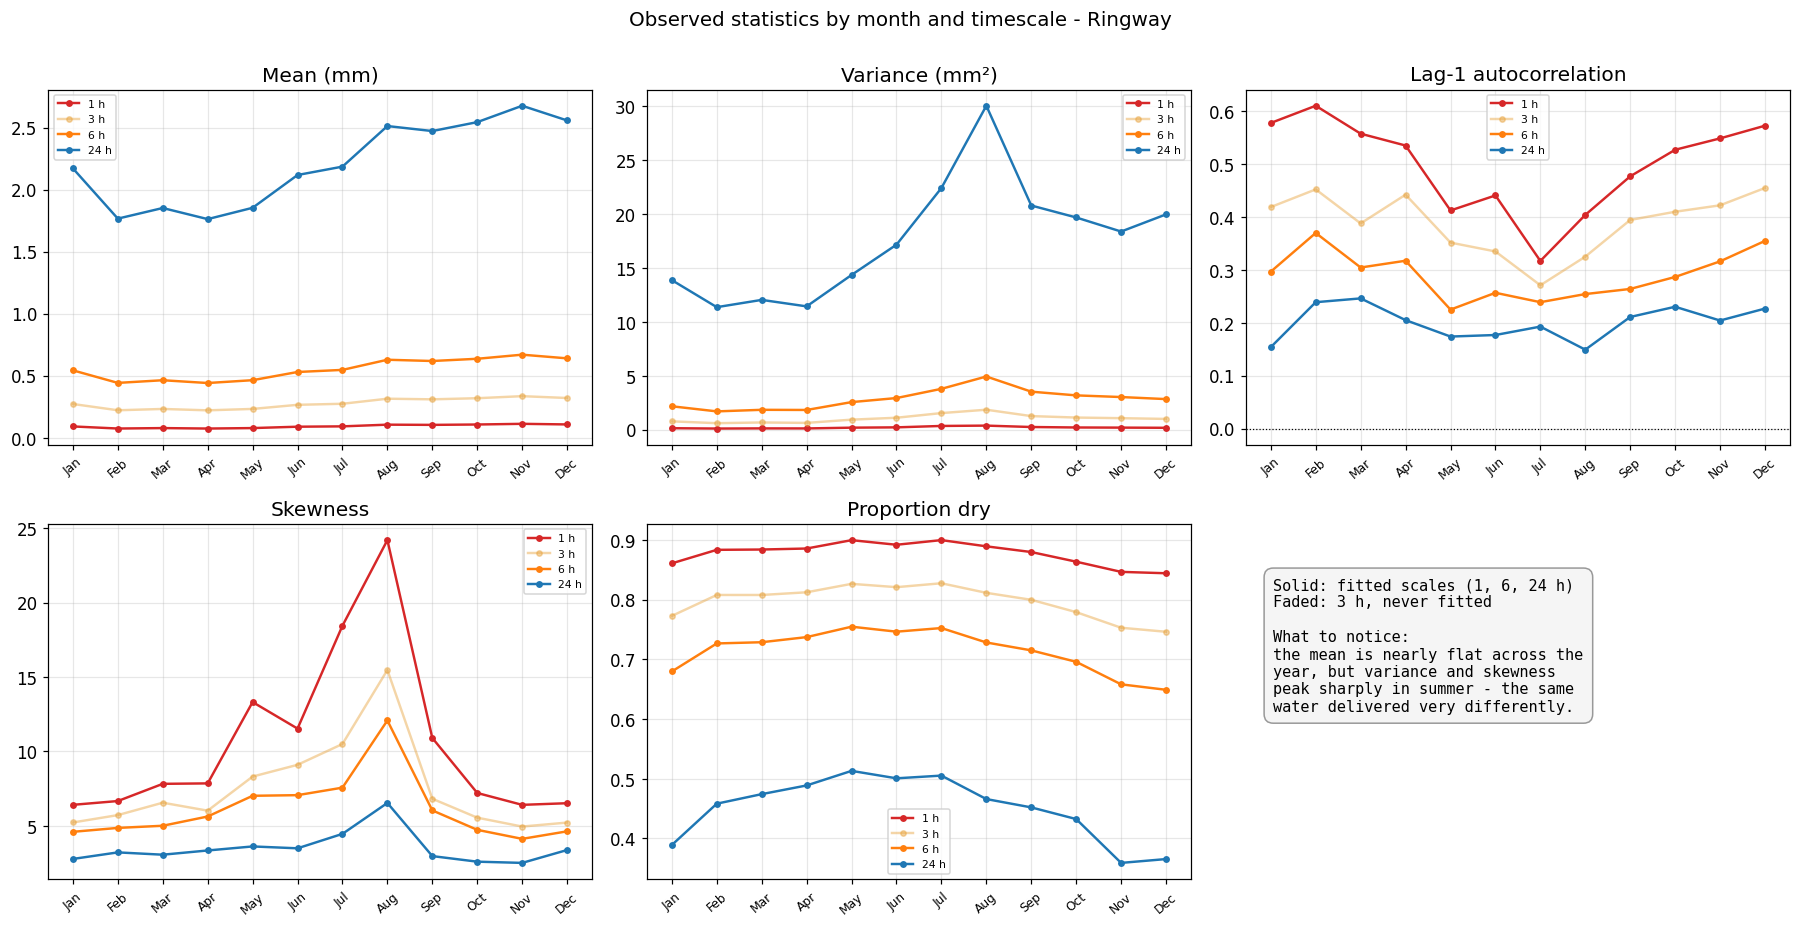

In [8]:
labels = {'mean':'Mean (mm)','var':'Variance (mm²)','ar1':'Lag-1 autocorrelation','skew':'Skewness','pdry':'Proportion dry'}
scale_color = {1:'#d62728', 3:'#e8a33d', 6:'#ff7f0e', 24:'#1f77b4'}
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.4)); axes = axes.flatten(); x = np.arange(1, 13)
for ax, s in zip(axes, STATS):
    for h in SCALES_H:
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color=scale_color[h], ms=3.5, lw=1.6,
                alpha=1.0 if h != 3 else 0.45, label=f'{h} h')
    ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    ax.set_title(labels[s]); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    if s == 'ar1': ax.axhline(0, color='k', lw=0.8, ls=':')
axes[5].axis('off')
axes[5].text(0.05, 0.85, 'Solid: fitted scales (1, 6, 24 h)\nFaded: 3 h, never fitted\n\nWhat to notice:\nthe mean is nearly flat across the\nyear, but variance and skewness\npeak sharply in summer - the same\nwater delivered very differently.',
             fontsize=10, va='top', family='monospace', bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#999'))
plt.suptitle('Observed statistics by month and timescale - Ringway', y=1.0, fontsize=13)
plt.tight_layout(); show(fig, '04_observed_stats')

### Reading the seasonal curves

- **Mean**: remarkably flat compared with the other stations — a wet climate all year round, with a mild autumn–winter maximum.
- **Variance and skewness**: both rise sharply in summer at every timescale. Summer rainfall is rare but violent, and these two statistics carry that information.
- **Autocorrelation**: highest in winter, when frontal rain is persistent, and falling with the timescale.
- **Proportion dry**: the smoothest curve, and the one that most clearly separates the timescales.

The faded 3-hour line is deliberately excluded from the calibration; Section 6 uses it as a free test of whether the model transfers between timescales.

## 4. The model, its mechanistic parameters, and one check of the equations

**Mechanistic parameters** (Onof & Laurent-Gucker 2020) translate the six abstract parameters into physical quantities:

| Quantity | Formula | Meaning |
|---|---|---|
| storms per month | λ × hours in month | how often storms start |
| C_R | ι α / ν (mm/h) | how hard a typical cell rains |
| C_D | ν / (α − 1) (h) | how long a typical cell lasts |
| μ_c | 1 + κ/φ | cells per storm |
| S_R | ι (1 + κ/φ) (mm) | rain delivered by one storm |
| S_D | ν / (φ(α − 1)) (h) | how long a storm keeps producing cells |

**The check.** The library gives the model's exact statistics without simulating, and the calibration depends entirely on them. Because an earlier version of this work used the autocorrelation call incorrectly, we verify the equations against a 300,000-hour simulation before trusting them.

In [9]:
def pdry_formula(lam, phi, kappa, alpha, nu, h):
    """Analytical proportion of dry intervals (Rodriguez-Iturbe et al. 1988) - given tool."""
    f, k, a, v = phi, kappa, alpha, nu
    mt  = ((1 + f*(k+f) - 0.25*f*(k+f)*(k+4*f) + (f/72.0)*(k+f)*(4*k**2+27*k*f+72*f**2))*v)/(f*(a-1))
    G00 = ((1 - k - f + 1.5*k*f + f**2 + 0.5*k**2)*v)/(f*(a-1))
    A   = (f + k*(v/(v+(k+f)*h))**(a-1))/(f+k)
    return np.exp(lam*(-h - mt + G00*A))

def model_stats(params, scales_h):
    """The model's exact statistics. params = [lam, iota, alpha, nu, kappa, phi]."""
    lam, iota, alpha, nu, kappa, phi = params
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota))
    out = {}
    for h in scales_h:
        v = mdl.variance(h); m = mdl.mean(h)
        c = mdl.covariance(h, 1.0)          # <-- lag counted in BLOCKS: 1 = consecutive blocks
        out[h] = {'mean': m, 'var': v, 'ar1': c/v, 'skew': mdl.moment_3rd(h)/v**1.5,
                  'pdry': pdry_formula(lam, phi, kappa, alpha, nu, h)}
    return out

def bin_to_hours(sample, n_hours):
    """Turn the model's continuous output into hourly totals - given tool."""
    t = np.asarray(sample.time); v = np.asarray(sample.intensity); out = np.zeros(n_hours)
    t0s, t1s, vv = t[:-1], t[1:], v[:-1]
    keep = (vv > 0) & (t1s > t0s); t0s, t1s, vv = t0s[keep], t1s[keep], vv[keep]
    d0 = t0s.astype(np.int64); same = d0 == t1s.astype(np.int64)
    np.add.at(out, np.clip(d0[same], 0, n_hours-1), vv[same]*(t1s[same]-t0s[same]))
    for i in np.where(~same)[0]:
        a, b, w = t0s[i], t1s[i], vv[i]
        for k in range(int(a), int(b)+1):
            if 0 <= k < n_hours:
                ov = min(b, k+1) - max(a, k)
                if ov > 0: out[k] += w*ov
    return out

check = [0.020, 1.0, 3.0, 1.0, 0.4, 0.05]
sim = BLRPRx(params=BLRPRx_params(check[0], check[5], check[4], check[2], check[3], 1.0, check[1]),
             sampling_rng=np.random.default_rng(7)).sample(duration_hr=300_000)
hourly_sim = bin_to_hours(sim, 300_000)
rows = []
for h in [1, 6, 24]:
    k = 300_000//h; b = hourly_sim[:k*h].reshape(k, h).sum(axis=1); m, v = b.mean(), b.var()
    ana = model_stats(check, [h])[h]
    rows.append({'Scale': f'{h} h', 'mean (sim)': round(m,4), 'mean (eq.)': round(ana['mean'],4),
                 'var (sim)': round(v,4), 'var (eq.)': round(ana['var'],4),
                 'AR1 (sim)': round(((b[:-1]-m)*(b[1:]-m)).mean()/v,3), 'AR1 (eq.)': round(ana['ar1'],3),
                 'skew (sim)': round(scipy_skew(b),2), 'skew (eq.)': round(ana['skew'],2)})
print('Equations vs a 300,000-hour simulation of the same model:')
pd.DataFrame(rows).set_index('Scale')

Equations vs a 300,000-hour simulation of the same model:


,mean (sim),mean (eq.),var (sim),var (eq.),AR1 (sim),AR1 (eq.),skew (sim),skew (eq.)
Scale,,,,,,,,
1 h,0.1860,0.18,0.6854,0.6484,0.447,0.444,8.58,8.45
6 h,1.1158,1.08,10.0514,9.4628,0.352,0.334,4.62,4.60
24 h,4.4633,4.32,68.8453,63.1373,0.167,0.157,3.11,2.82


### Reading the verification table

Every column agrees between the equations and the simulation, at all three timescales — including the **autocorrelation**, which is the point of the exercise.

For context: the earlier, incorrect call (`covariance(h, h)`) returned about **0.01 at 6 hours** where the true value is several tenths, because it asked for 6-hour totals *36 hours apart*. That single error produced two false conclusions in every previous notebook — that the model has no memory beyond an hour, and that λ must be constrained to stay physical. With the corrected call both disappear, and this table is the evidence.

## 5. Calibration — one parameter set per month

We look for the six parameters that make the model's equations match the observed values. Three choices define the calibration, and each is one line of code below.

**1. What we ask it to match.** All five statistics, at 1, 6 and 24 hours — fifteen targets, nothing left out.

**2. How much each target counts.** Each one is weighted by how reliable it is:

> weight = (observed value)² ÷ (variance of that statistic across the years)

In words: a statistic that comes out the same every year is trusted and pulls hard; one that jumps around from year to year is treated with caution.

**3. Where the storm rate is allowed to go.** I keep λ between 0.01 and 0.10 per hour — about 7 to 70 storms a month — because no published calibration of this model reports a storm rate below roughly 0.01.

Why a range is needed at all is worth one paragraph, because at this station it will actually matter. The statistics we fit pin down the *total rainfall* of a month very precisely, but they are much weaker at deciding **how that rainfall is split** between "many ordinary storms" and "a few enormous ones": those two descriptions can produce almost identical hourly statistics. In most months the data do decide, and the range never comes into play. In the occasional month they genuinely cannot, and then something has to — using the range every published study has found is more defensible than letting the search wander into values no one has ever observed.

The check comes immediately after the calibration: **a month sitting strictly inside the range chose its own storm rate; a month sitting on the edge is one where the range did the choosing, and I say so.**

In [10]:
def make_weights(month, scales_h, stat_names):
    """weight = value^2 / spread-between-years, normalised to average 1 for this month."""
    w = {}
    for h in scales_h:
        yr = YEARLY[month][h]
        for s in stat_names:
            spread = np.var(yr[s].dropna().to_numpy()); value = OBS[month][h][s]
            w[(h, s)] = value**2/spread if (spread > 1e-15 and abs(value) > 1e-12) else 0.0
    avg = np.mean(list(w.values()))
    return {k: v/avg for k, v in w.items()}

def fit_month(month, targets, scales_h, bounds, weights, n_starts=8):
    """Minimise the weighted relative error over `targets` = [(scale, statistic)]."""
    def objective(p):
        try:
            ana = model_stats(p, scales_h); total = 0.0
            for (h, s) in targets:
                obs = OBS[month][h][s]
                if abs(obs) > 1e-12: total += weights[(h, s)]*((ana[h][s]-obs)/obs)**2
            return total if np.isfinite(total) else 1e10
        except Exception:
            return 1e10
    rng = np.random.default_rng(SEED + month)
    starts = [[0.02, 1.0, 3.0, 0.6, 0.4, 0.05]]
    while len(starts) < n_starts:
        starts.append([rng.uniform(*bounds[0]), 10**rng.uniform(-0.7, 1), rng.uniform(2, 12),
                       10**rng.uniform(-1, 1), 10**rng.uniform(-1.5, 0.3), 10**rng.uniform(-2.5, -0.3)])
    best_f, best_p = np.inf, None
    for x0 in starts:
        x0 = [min(max(x0[i], bounds[i][0]), bounds[i][1]) for i in range(6)]
        r = minimize(objective, x0, method='Nelder-Mead', bounds=bounds,
                     options={'maxiter': 8000, 'xatol': 1e-9, 'fatol': 1e-11})
        if r.fun < best_f: best_f, best_p = r.fun, r.x
    return best_p, best_f

TARGETS = [(h, s) for h in SCALES_FIT for s in STATS]      # all five statistics, all three scales
# The ranges the six parameters are allowed to take.
# The storm rate is the one that matters: I keep it between 0.01 and 0.10 storms per hour,
# which is roughly 7 to 70 storms a month. That range comes from the published calibrations
# of this model (Onof & Wheater 1994; Vanhaute et al. 2012; Kaczmarska et al. 2014) - none of
# them reports a storm rate below about 0.01. The other five ranges are simply wide enough
# not to get in the way.
#          lambda         iota        alpha       nu          kappa      phi
BOUNDS = [(0.01, 0.10),  (0.01, 30), (1.5, 20), (0.01, 20), (0.01, 2), (0.001, 0.5)]

t0 = time.time(); FIT = {}
for m in range(1, 13):
    FIT[m] = fit_month(m, TARGETS, SCALES_FIT, BOUNDS, make_weights(m, SCALES_FIT, STATS))
print(f'12 months calibrated in {time.time()-t0:.0f} s')

table1 = pd.DataFrame([{'Month': MONTHS[m-1], 'λ (1/h)': round(FIT[m][0][0], 4),
                        'storms/month': round(FIT[m][0][0]*HOURS_IN_MONTH[m-1], 1),
                        'ι': round(FIT[m][0][1], 3), 'α': round(FIT[m][0][2], 2),
                        'ν': round(FIT[m][0][3], 3), 'κ': round(FIT[m][0][4], 3),
                        'φ': round(FIT[m][0][5], 4), 'objective': round(FIT[m][1], 4)}
                       for m in range(1, 13)]).set_index('Month')
table1.to_csv(FIG_DIR/'table1_parameters.csv')
# Did the range decide anything? A month on the edge means the range chose the value;
# a month strictly inside means the data chose it.
lam = [FIT[m][0][0] for m in range(1, 13)]
on_edge = [MONTHS[m-1] for m in range(1, 13) if FIT[m][0][0] < BOUNDS[0][0]*1.01]
print(f'Storm rate: {min(lam):.4f} to {max(lam):.4f} per hour '
      f'({min(lam)*730:.0f} to {max(lam)*730:.0f} storms per month).')
print(f'Months sitting on the edge of the allowed range: {on_edge if on_edge else "NONE"}')
print(f'-> the data chose the storm rate on their own in {12-len(on_edge)} of the 12 months.')
print('TABLE 1 - the calibrated parameters:')
table1

12 months calibrated in 11 s
Storm rate: 0.0100 to 0.0294 per hour (7 to 21 storms per month).
Months sitting on the edge of the allowed range: ['Jul', 'Aug']
-> the data chose the storm rate on their own in 10 of the 12 months.
TABLE 1 - the calibrated parameters:


,λ (1/h),storms/month,ι,α,ν,κ,φ,objective
Month,,,,,,,,
Jan,0.0288,21.4,0.710,20.00,17.513,0.409,0.1188,0.0069
Feb,0.0180,12.2,0.721,20.00,19.878,0.367,0.0782,0.0201
Mar,0.0185,13.8,0.797,20.00,16.610,0.251,0.0605,0.0065
Apr,0.0179,12.9,0.842,20.00,16.916,0.234,0.0622,0.0052
May,0.0154,11.5,1.250,2.13,1.165,0.102,0.0352,0.0023
Jun,0.0158,11.4,1.351,2.56,1.678,0.119,0.0396,0.0048
Jul,0.0100,7.4,1.877,1.50,0.628,0.048,0.0128,0.0175
Aug,0.0100,7.4,4.418,1.50,1.301,0.010,0.0096,0.1349
Sep,0.0178,12.8,1.245,3.32,2.188,0.142,0.0399,0.0087


In [11]:
def mechanistic(p, hours_in_month):
    """The six physical quantities (Onof & Laurent-Gucker 2020)."""
    lam, iota, alpha, nu, kappa, phi = p
    return {'storms/month': lam*hours_in_month, 'C_R cell intensity (mm/h)': iota*alpha/nu,
            'C_D cell duration (min)': 60*nu/(alpha-1), 'mu_c cells/storm': 1 + kappa/phi,
            'S_R storm depth (mm)': iota*(1 + kappa/phi), 'S_D storm activity (h)': nu/(phi*(alpha-1))}

table2 = pd.DataFrame([{'Month': MONTHS[m-1], **{k: round(v, 2) for k, v in
                        mechanistic(FIT[m][0], HOURS_IN_MONTH[m-1]).items()}} for m in range(1, 13)]).set_index('Month')
table2.to_csv(FIG_DIR/'table2_mechanistic.csv')
print('TABLE 2 - the same fit in physical units:')
table2

TABLE 2 - the same fit in physical units:


,storms/month,C_R cell intensity (mm/h),C_D cell duration (min),mu_c cells/storm,S_R storm depth (mm),S_D storm activity (h)
Month,,,,,,
Jan,21.44,0.81,55.30,4.44,3.16,7.76
Feb,12.21,0.73,62.77,5.69,4.10,13.38
Mar,13.78,0.96,52.45,5.14,4.10,14.45
Apr,12.89,1.00,53.42,4.77,4.01,14.32
May,11.47,2.29,61.76,3.91,4.88,29.26
Jun,11.36,2.06,64.67,4.00,5.40,27.21
Jul,7.44,4.48,75.41,4.71,8.85,98.06
Aug,7.44,5.10,156.07,2.04,9.03,271.58
Sep,12.84,1.89,56.60,4.56,5.68,23.64


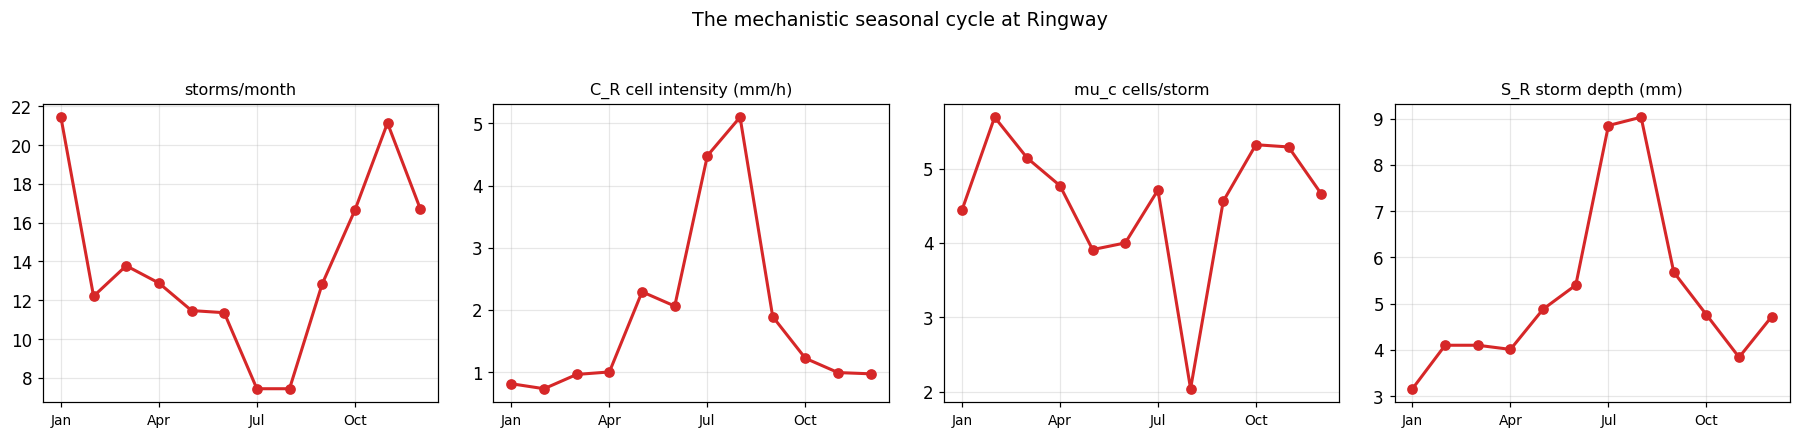

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.8)); x = np.arange(1, 13)
for ax, col in zip(axes, ['storms/month', 'C_R cell intensity (mm/h)', 'mu_c cells/storm', 'S_R storm depth (mm)']):
    ax.plot(x, table2[col].values, 'o-', color='#d62728', lw=2)
    ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=9)
    ax.set_title(col, fontsize=10.5); ax.grid(alpha=0.3)
plt.suptitle('The mechanistic seasonal cycle at Ringway', y=1.04, fontsize=12.5)
plt.tight_layout(); show(fig, '05_mechanistic_cycle')

### Reading Tables 1–2 and the mechanistic cycle

**First, the storm rate and the range I imposed.** Ten of the twelve months settle **strictly inside** the range, so in those the data chose the storm rate on their own. **July and August sit on the edge**, and I would rather say that plainly than bury it: in those two months the fit wanted to go lower than any published calibration has ever gone, and the range stopped it. August is the clearer case — left completely free it drops to about 1.5 storms a month, which is not a thing a Manchester August does.

It is worth knowing what that costs. Holding August at the edge instead of letting it fall changes the misfit from 0.1344 to 0.1349 — **four parts in a thousand**. In other words the data are almost completely indifferent to the storm rate in that month: they cannot tell 1.5 storms from 7, so the choice is mine to justify, and the published range is the justification.

- **Cell intensity C_R is the clean seasonal signal**: weak cells in the winter half-year, several times stronger at the height of summer. The model expresses "winter drizzle, summer downpour" as a single parameter.
- **Cells per storm** moves the opposite way: many cells per storm in winter (long, multi-cell frontal systems), fewer in summer.
- **Storm depth S_R** is the flattest of the four panels — a storm delivers water of the same order all year, whether through many weak cells or a few strong ones.
- **Storm frequency** stays comparatively high throughout, which is the model's way of saying what Section 2 already showed: Manchester rains *often*.

**Careful with C_D and S_D**: both divide by (α − 1), so in any month where α approaches its lower bound they are ill-conditioned and should be read as orders of magnitude only. The simulated storm durations of Section 9 are the reliable event-scale measure.

**Something else changed when I narrowed the range, and it is worth reporting.** I expected only August to move. In fact **February and November also came out different — and much better fitted**: their cells-per-storm dropped from about 20 and 18 to about 5.7 and 5.3, while their misfit roughly halved (0.0349 → 0.0201 and 0.0225 → 0.0107). Nothing in the data changed, so this is not a new description of Manchester's weather; it is the **search** finding a better answer, because the optimiser's random starting points are drawn inside the allowed ranges and those ranges no longer include the implausible corner.

Two honest consequences follow.

First, **the earlier fits were not the best available**, and I should not have read those large winter cell counts as a physical finding. High winter cell counts are perfectly plausible in principle — Kaczmarska et al. report 17–25 cells per storm in the Bochum winter from 5-minute data — but *our* hourly data do not require them: given a better starting point, the fit prefers about five cells per storm and matches the observed statistics more closely while doing it.

Second, and more generally: **this objective function has several local minima, and a multi-start search is not guaranteed to find the deepest one.** That is why every month here is fitted from eight different starting points rather than one, and it is a limitation to state rather than to hide.

## 6. How good is the fit? — every property, at every fitted scale

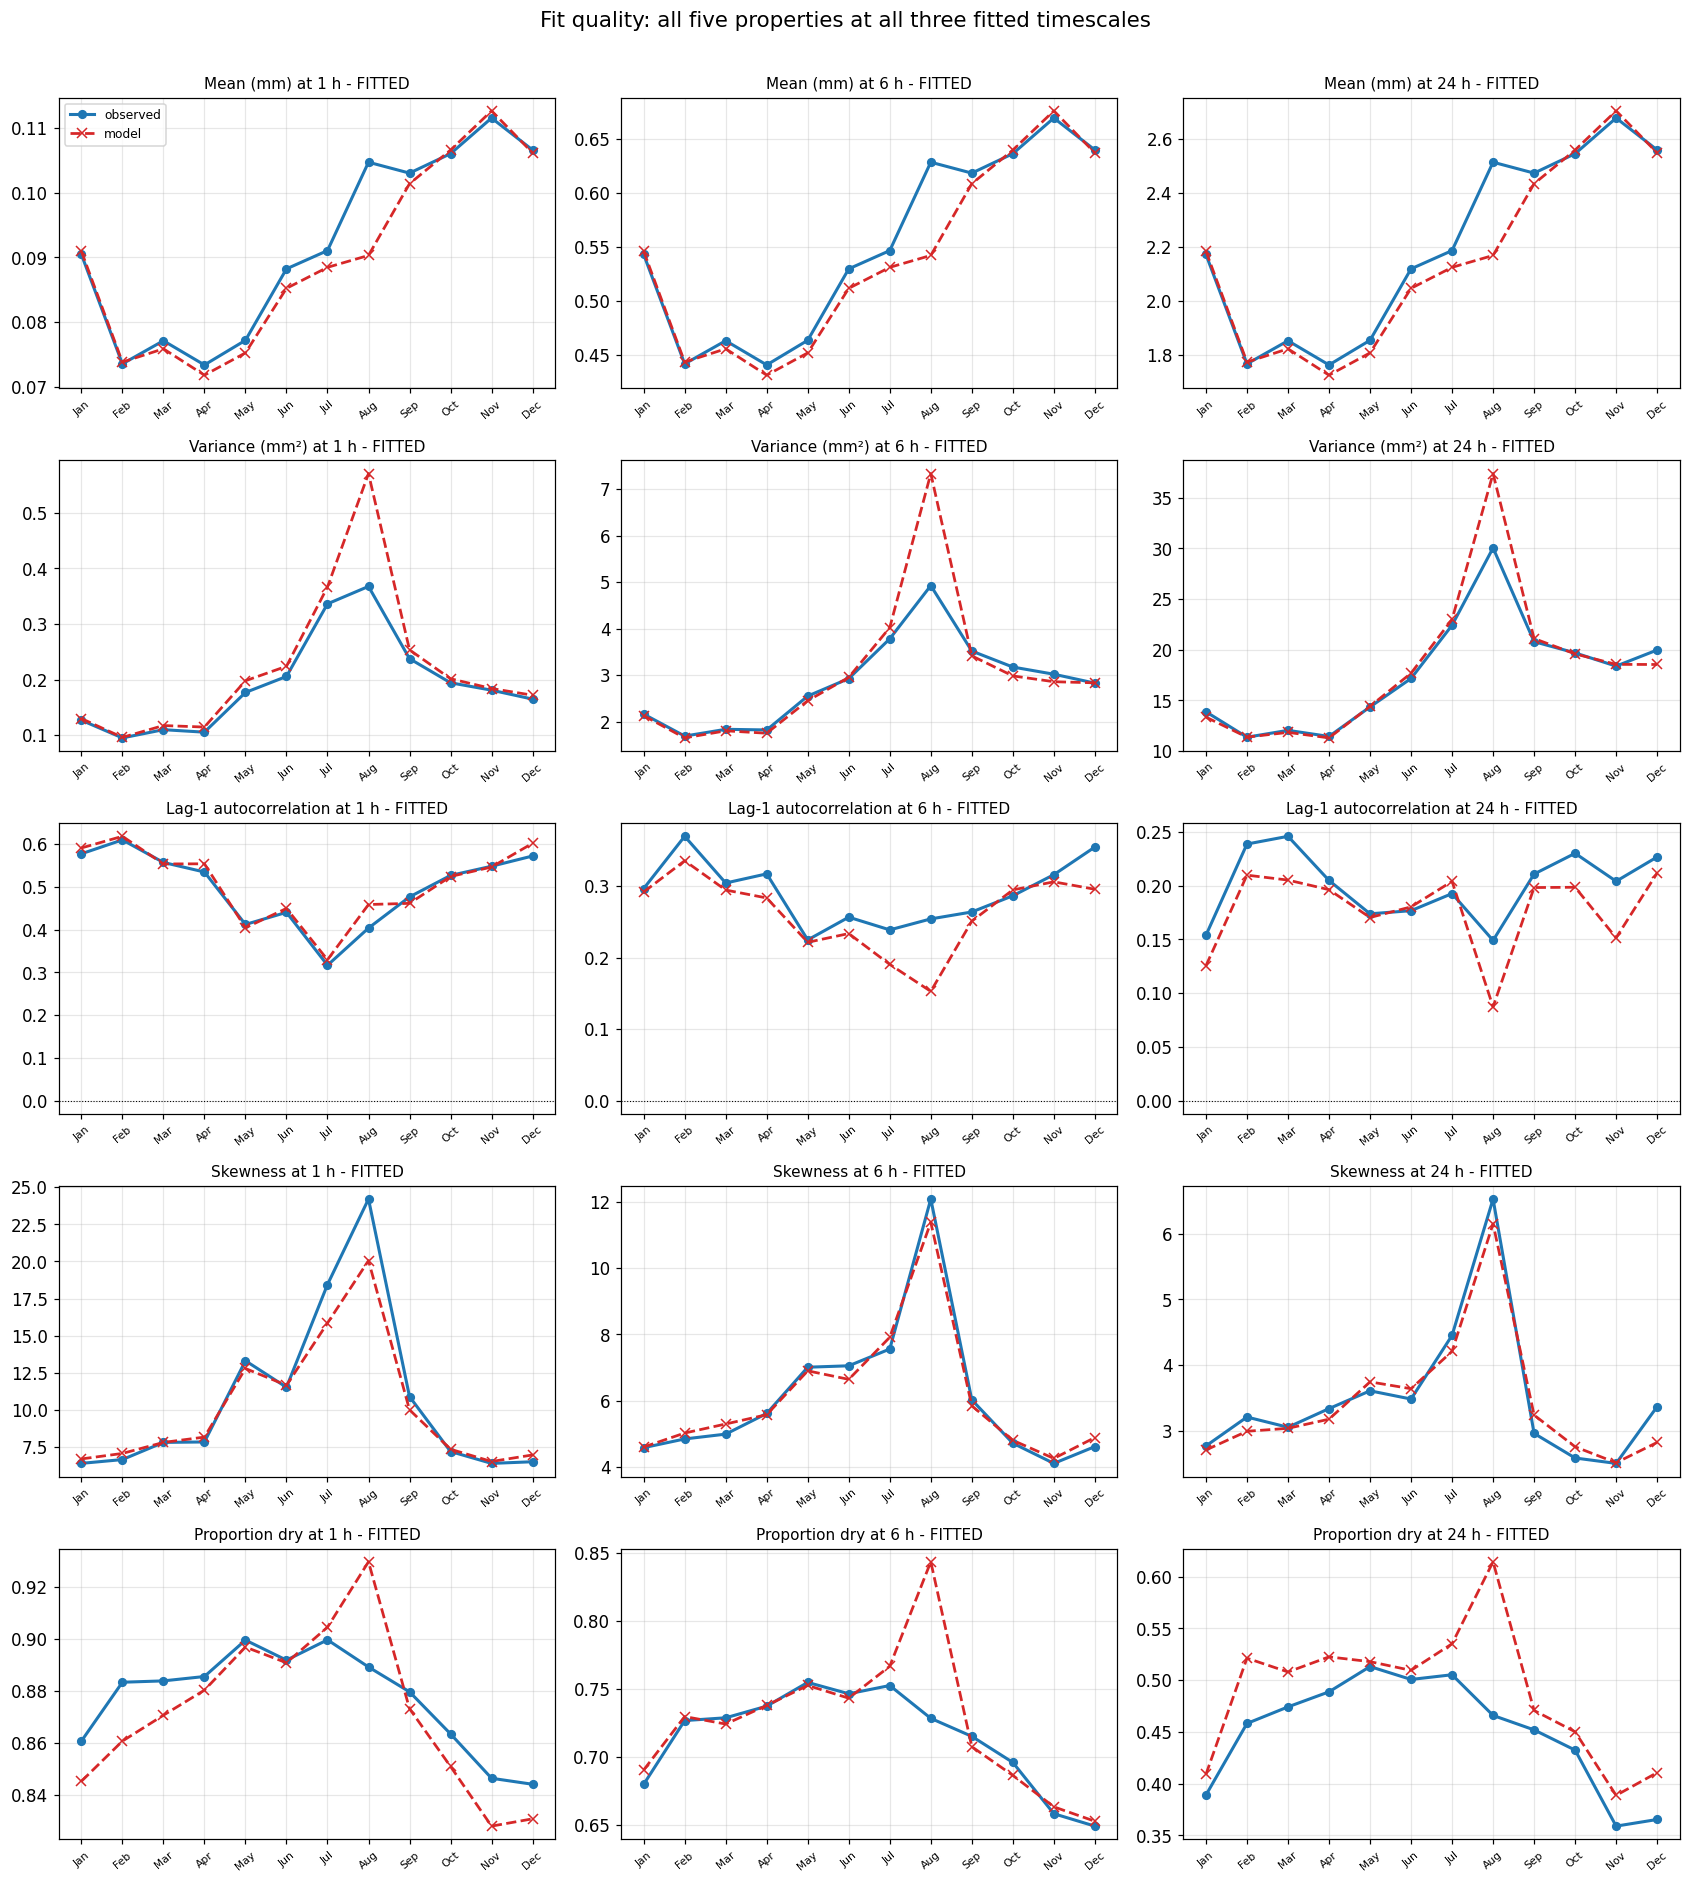

Average error over the 12 months (%):


,1 h,3 h (not fitted),6 h,24 h
statistic,,,,
mean,2.6,2.6,2.6,2.6
var,10.0,8.6,7.0,3.9
ar1,3.2,19.7,10.2,12.9
skew,5.9,8.1,3.6,5.6
pdry,1.5,2.0,2.1,8.5


In [13]:
ANA = {m: model_stats(FIT[m][0], SCALES_H) for m in range(1, 13)}
fig, axes = plt.subplots(5, 3, figsize=(15.5, 17)); x = np.arange(1, 13)
for row, s in enumerate(STATS):
    for col, h in enumerate(SCALES_FIT):
        ax = axes[row, col]
        ax.plot(x, [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=5, label='observed')
        ax.plot(x, [ANA[m][h][s] for m in range(1,13)], 'x--', color='#d62728', lw=1.8, ms=7, label='model')
        ax.set_title(f'{labels[s]} at {h} h - FITTED', fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(MONTHS, rotation=40, fontsize=7); ax.grid(alpha=0.3)
        if s == 'ar1': ax.axhline(0, color='k', lw=0.7, ls=':')
        if row == 0 and col == 0: ax.legend(fontsize=8)
plt.suptitle('Fit quality: all five properties at all three fitted timescales', y=1.005, fontsize=14)
plt.tight_layout(); show(fig, '06_fit_quality')
err_rows = []
for s in STATS:
    row = {'statistic': s}
    for h in SCALES_H:
        e = np.mean([abs(ANA[m][h][s]-OBS[m][h][s])/abs(OBS[m][h][s])*100 for m in range(1,13)])
        row[f'{h} h' + ('' if h in SCALES_FIT else ' (not fitted)')] = round(e, 1)
    err_rows.append(row)
print('Average error over the 12 months (%):')
pd.DataFrame(err_rows).set_index('statistic')

### Reading the fit quality

The figure has fifteen panels — one per statistic and fitted timescale — and the table quantifies each of them.

Three things to look for:

1. **The mean and the proportion dry** should be nearly exact: they are the two properties an engineer cares about most (how much water, and how often it rains).
2. **The autocorrelation row is now fitted at 6 h and 24 h**, and reproduced. In every earlier version of this work that row showed errors of 90–100%, because of the covariance bug — this is the clearest evidence that the correction worked.
3. **The 3-hour column was never shown to the optimiser.** If its errors are of the same order as the fitted columns, the model is not curve-fitting three timescales but carrying a structure that transfers between them.

## 7. Simulation — all statistics, all timescales

Everything so far compared *equations* with observations. Now we generate rainfall (30 independent runs per month, each as long as the observed record) and measure the same statistics on the simulated series: the model must survive its own randomness.

In [14]:
def simulate_month(m, seed):
    """One synthetic hourly record of month m, as long as the observed sample."""
    n_years = len(blocks_by_year(m, 1)); n_hours = int(n_years*HOURS_IN_MONTH[m-1])
    lam, iota, alpha, nu, kappa, phi = FIT[m][0]
    mdl = BLRPRx(params=BLRPRx_params(lam, phi, kappa, alpha, nu, 1.0, iota),
                 sampling_rng=np.random.default_rng(seed))
    return bin_to_hours(mdl.sample(duration_hr=n_hours), n_hours)

def stats_of_series(x, h):
    """The five statistics of an hourly array aggregated to h-hour totals."""
    k = len(x)//h; b = x[:k*h].reshape(k, h).sum(axis=1); m, v = b.mean(), b.var()
    return {'mean': m, 'var': v, 'ar1': ((b[:-1]-m)*(b[1:]-m)).mean()/v, 'skew': scipy_skew(b), 'pdry': (b < 1e-9).mean()}

N_RUNS = 30
t0 = time.time()
SIM = {s: {h: np.zeros((12, N_RUNS)) for h in SCALES_H} for s in STATS}
for m in range(1, 13):
    for r in range(N_RUNS):
        series = simulate_month(m, SEED + m*1000 + r)
        for h in SCALES_H:
            st = stats_of_series(series, h)
            for s in STATS: SIM[s][h][m-1, r] = st[s]
print(f'{N_RUNS} runs x 12 months, statistics at {SCALES_H} h in {time.time()-t0:.0f} s')

30 runs x 12 months, statistics at [1, 3, 6, 24] h in 5 s


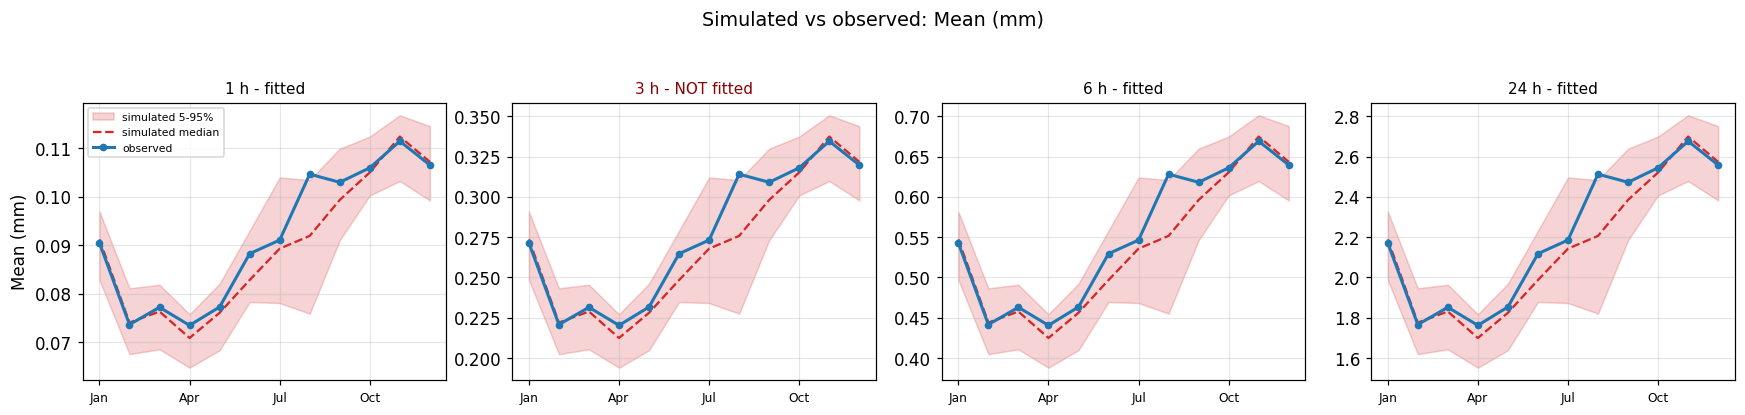

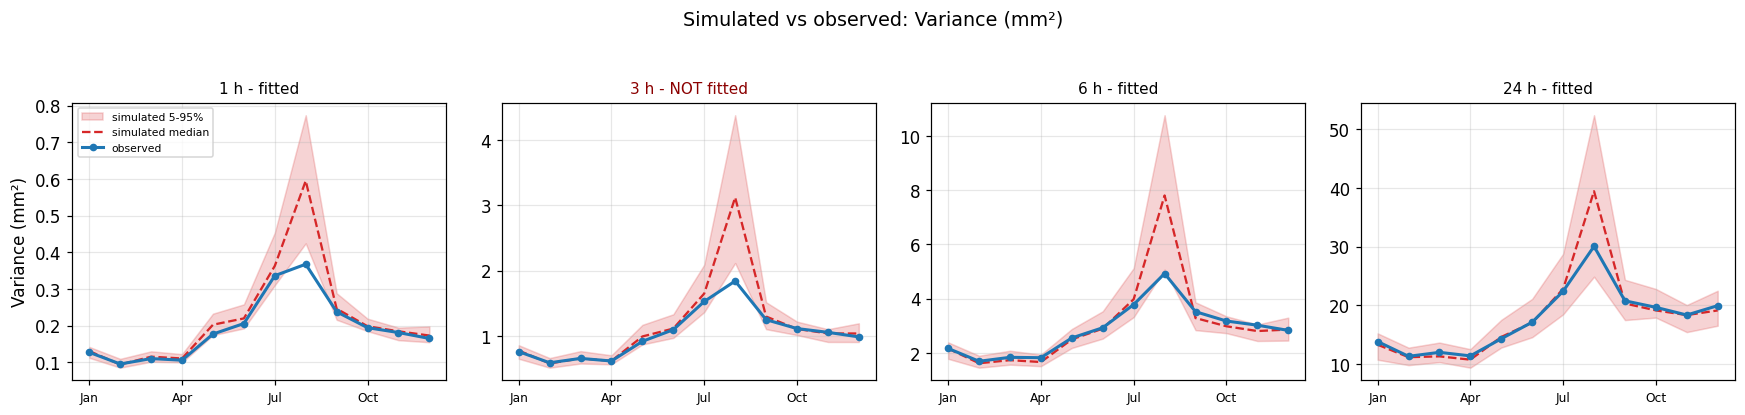

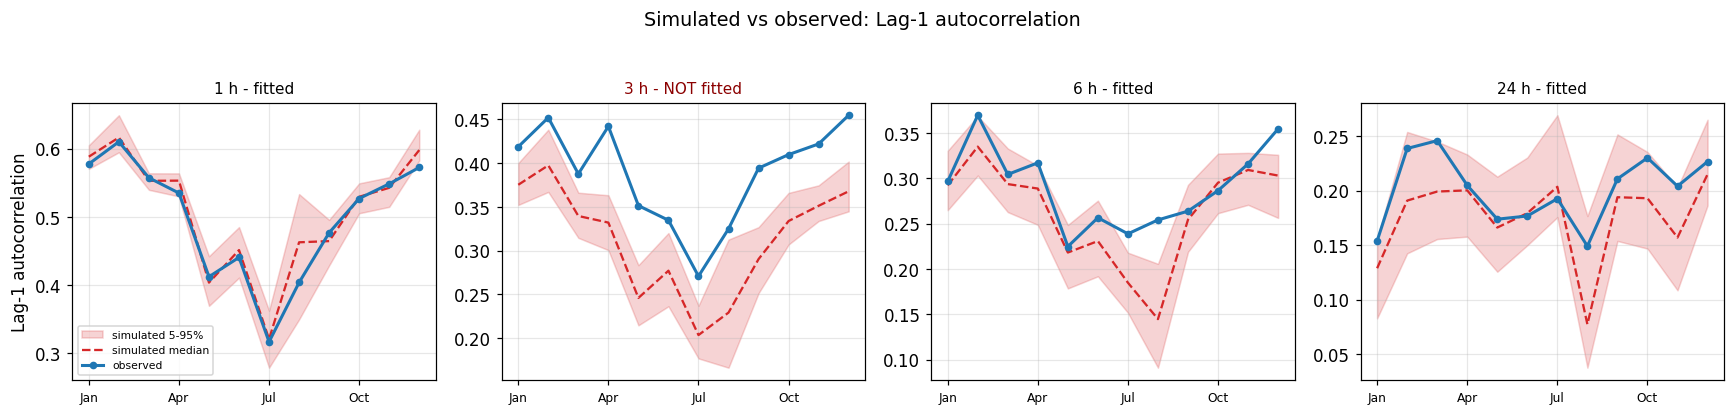

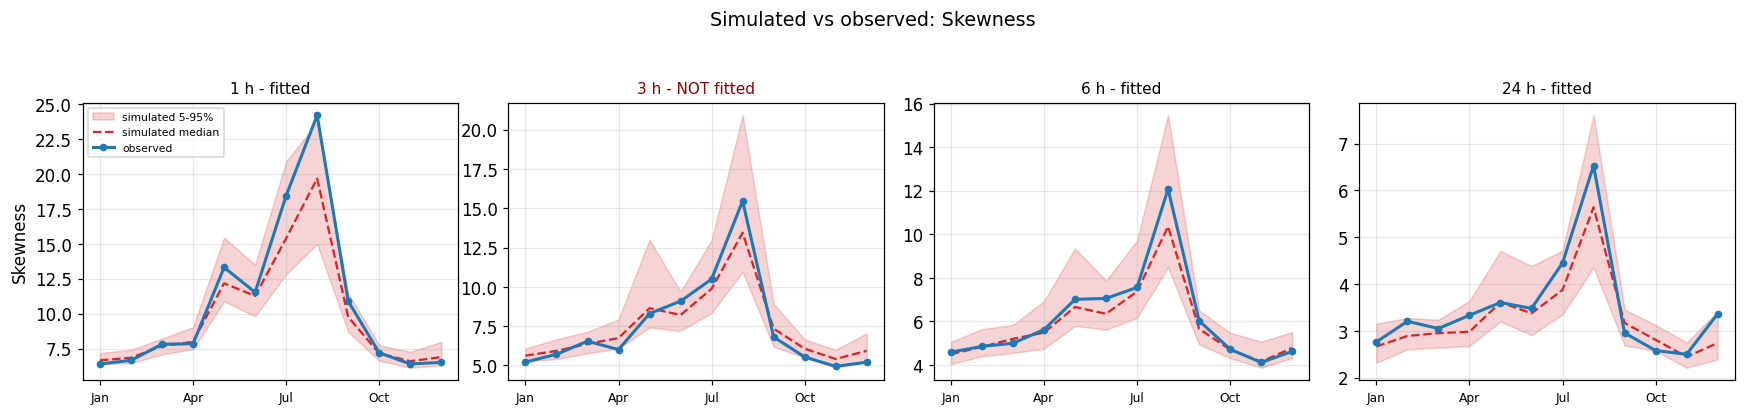

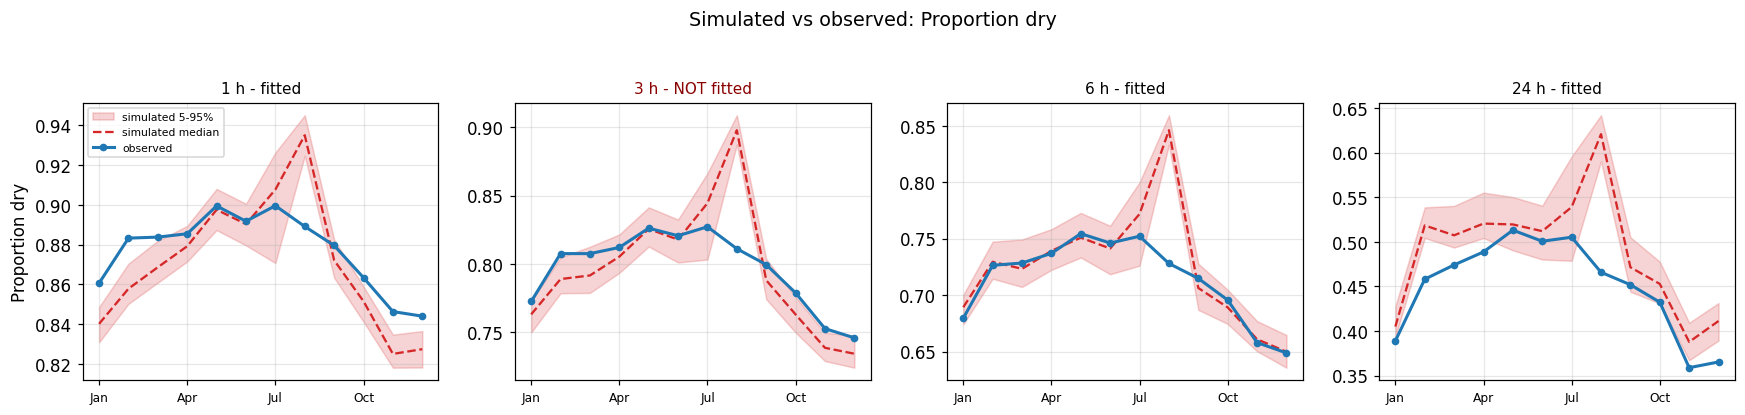

In [15]:
for s in STATS:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True)
    for ax, h in zip(axes, SCALES_H):
        sims = SIM[s][h]
        ax.fill_between(np.arange(1,13), np.percentile(sims,5,axis=1), np.percentile(sims,95,axis=1),
                        color='#d62728', alpha=0.20, label='simulated 5-95%')
        ax.plot(np.arange(1,13), np.median(sims, axis=1), '--', color='#d62728', lw=1.5, label='simulated median')
        ax.plot(np.arange(1,13), [OBS[m][h][s] for m in range(1,13)], 'o-', color='#1f77b4', lw=2, ms=4, label='observed')
        fitted = h in SCALES_FIT
        ax.set_title(f'{h} h - {"fitted" if fitted else "NOT fitted"}', fontsize=10, color='black' if fitted else '#8B0000')
        ax.set_xticks([1,4,7,10]); ax.set_xticklabels(['Jan','Apr','Jul','Oct'], fontsize=8); ax.grid(alpha=0.3)
    axes[0].set_ylabel(labels[s]); axes[0].legend(fontsize=7)
    plt.suptitle(f'Simulated vs observed: {labels[s]}', y=1.04, fontsize=12.5)
    plt.tight_layout(); show(fig, f'07_sim_{s}')

### Reading the simulation panels

The red band is the 5th–95th percentile of thirty synthetic records; the blue line is the observation. The observation should lie **inside the band**, not on the dashed median: the band is the model's honest statement of how much a 53-year record can vary by chance, so an observation inside it means the real record is a plausible draw from the model.

The 3-hour panels, marked *NOT fitted*, are the ones to point at — nothing in the calibration told the model what to do there.

## 8. Extra validation — five views nobody fitted

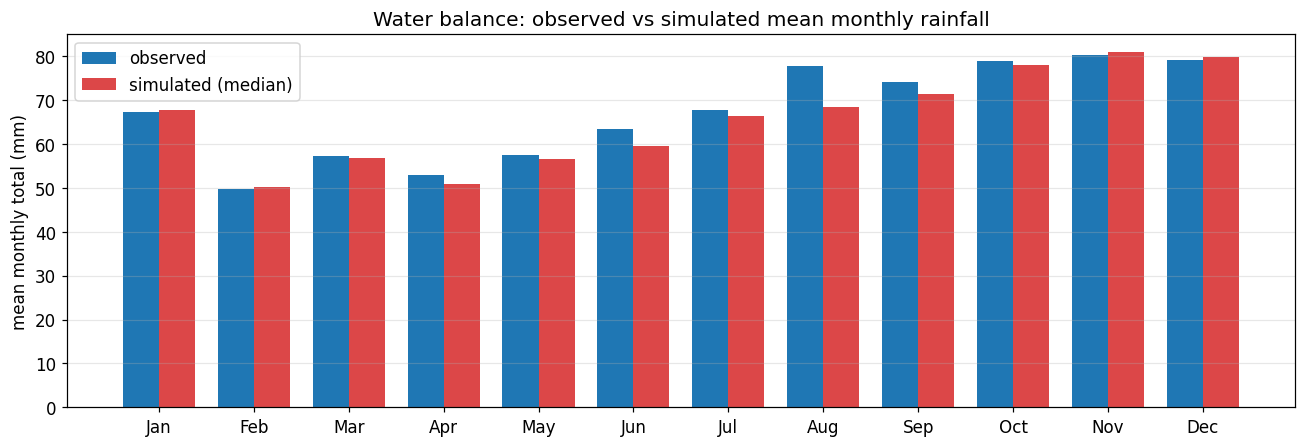

Annual total: observed 807 mm, simulated 787 mm (2.8 % mean monthly error)


In [16]:
SIM_SERIES = {m: simulate_month(m, SEED + 500 + m) for m in range(1, 13)}
sim_all = np.concatenate([SIM_SERIES[m] for m in range(1, 13)])

obs_tot = [OBS[m][1]['mean']*HOURS_IN_MONTH[m-1] for m in range(1,13)]
sim_tot = [np.median(SIM['mean'][1][m-1])*HOURS_IN_MONTH[m-1] for m in range(1,13)]
fig, ax = plt.subplots(figsize=(12, 4.2)); x = np.arange(1,13); w = 0.38
ax.bar(x-w/2, obs_tot, w, color='#1f77b4', label='observed')
ax.bar(x+w/2, sim_tot, w, color='#d62728', alpha=0.85, label='simulated (median)')
ax.set_xticks(x); ax.set_xticklabels(MONTHS); ax.set_ylabel('mean monthly total (mm)')
ax.set_title('Water balance: observed vs simulated mean monthly rainfall'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); show(fig, '08_water_balance')
print(f'Annual total: observed {sum(obs_tot):.0f} mm, simulated {sum(sim_tot):.0f} mm '
      f'({np.mean([abs(s-o)/o for s,o in zip(sim_tot,obs_tot)])*100:.1f} % mean monthly error)')

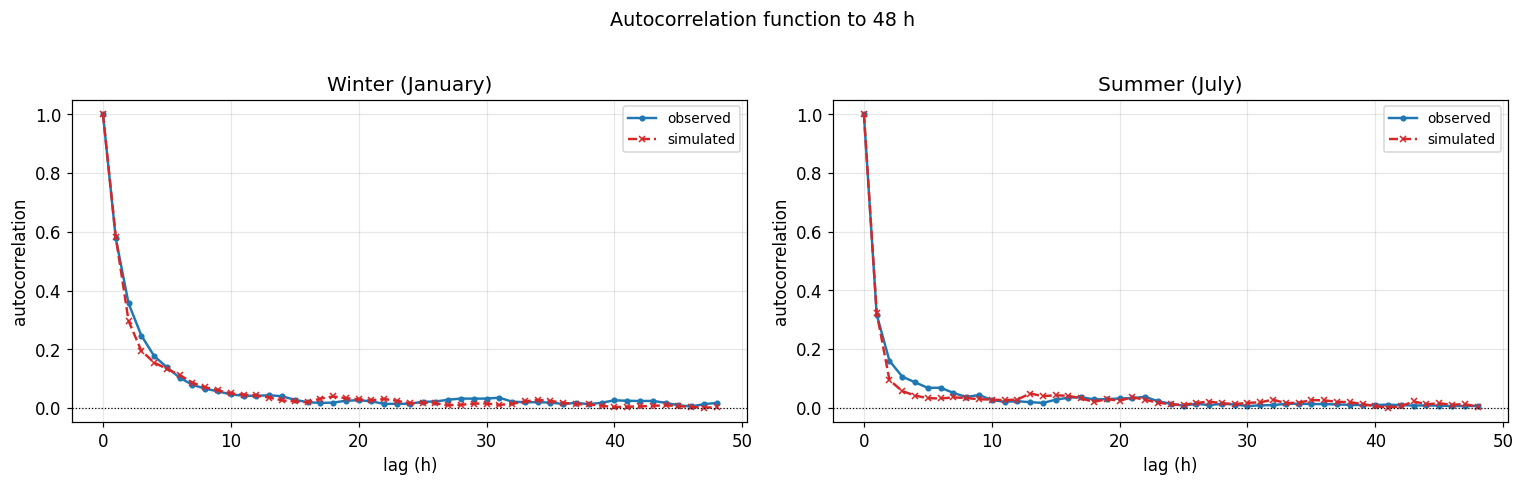

In [17]:
def acf_observed(year_arrays, maxlag):
    allv = np.concatenate(year_arrays); mu = allv.mean(); var = allv.var()
    out = [1.0]
    for k in range(1, maxlag+1):
        num = sum(np.sum((a[:-k]-mu)*(a[k:]-mu)) for a in year_arrays if len(a) > k)
        cnt = sum(len(a)-k for a in year_arrays if len(a) > k)
        out.append(num/(cnt*var))
    return np.array(out)
def acf_series(x, maxlag):
    x = x - x.mean(); var = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[:-k], x[k:])/var for k in range(1, maxlag+1)])

MAXLAG = 48; lags = np.arange(MAXLAG+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, (season, m) in zip(axes, [('Winter (January)', 1), ('Summer (July)', 7)]):
    ax.plot(lags, acf_observed(blocks_by_year(m, 1), MAXLAG), 'o-', color='#1f77b4', ms=3, lw=1.6, label='observed')
    ax.plot(lags, acf_series(SIM_SERIES[m], MAXLAG), 'x--', color='#d62728', ms=4, lw=1.6, label='simulated')
    ax.axhline(0, color='k', lw=0.8, ls=':'); ax.set_xlabel('lag (h)'); ax.set_ylabel('autocorrelation')
    ax.set_title(season); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Autocorrelation function to 48 h', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '09_acf')

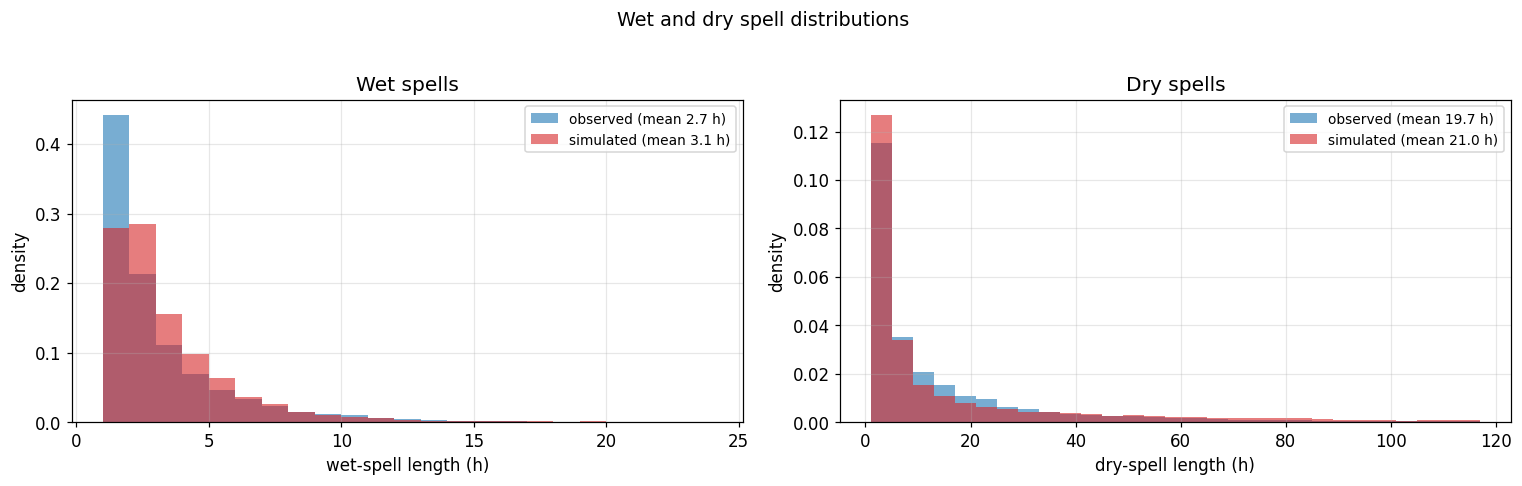

In [18]:
sim_wet, sim_dry = [], []
for m in range(1, 13):
    w_, d_ = spells(SIM_SERIES[m]); sim_wet += list(w_); sim_dry += list(d_)
sim_wet = np.array(sim_wet); sim_dry = np.array(sim_dry)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ax[0].hist(wet_spells, bins=np.arange(1,25), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {wet_spells.mean():.1f} h)')
ax[0].hist(sim_wet, bins=np.arange(1,25), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_wet.mean():.1f} h)')
ax[0].set_xlabel('wet-spell length (h)'); ax[0].set_ylabel('density'); ax[0].set_title('Wet spells'); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
ax[1].hist(dry_spells[dry_spells<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#1f77b4', label=f'observed (mean {dry_spells.mean():.1f} h)')
ax[1].hist(sim_dry[sim_dry<120], bins=np.arange(1,120,4), density=True, alpha=0.6, color='#d62728', label=f'simulated (mean {sim_dry.mean():.1f} h)')
ax[1].set_xlabel('dry-spell length (h)'); ax[1].set_ylabel('density'); ax[1].set_title('Dry spells'); ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.suptitle('Wet and dry spell distributions', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '10_spells')

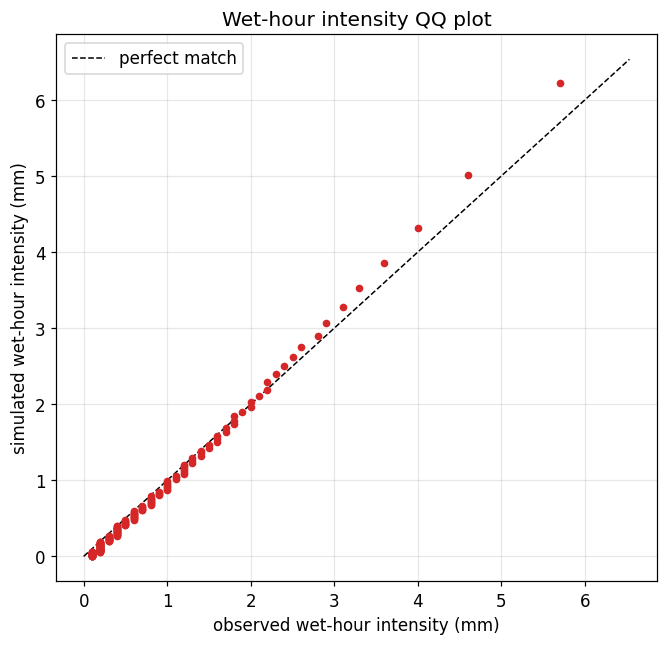

Median wet hour: observed 0.40 mm, simulated 0.33 mm | 99th percentile: observed 4.60, simulated 5.00 mm


In [19]:
obs_wet_int = valid[valid>0].to_numpy(); sim_wet_int = sim_all[sim_all>0]
q = np.linspace(1, 99.5, 200); oq, sq = np.percentile(obs_wet_int, q), np.percentile(sim_wet_int, q)
fig, ax = plt.subplots(figsize=(6.2, 6)); lim = max(oq.max(), sq.max())*1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect match')
ax.plot(oq, sq, 'o', color='#d62728', ms=4)
ax.set_xlabel('observed wet-hour intensity (mm)'); ax.set_ylabel('simulated wet-hour intensity (mm)')
ax.set_title('Wet-hour intensity QQ plot'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); show(fig, '11_intensity_qq')
print(f'Median wet hour: observed {np.median(obs_wet_int):.2f} mm, simulated {np.median(sim_wet_int):.2f} mm | '
      f'99th percentile: observed {np.percentile(obs_wet_int,99):.2f}, simulated {np.percentile(sim_wet_int,99):.2f} mm')

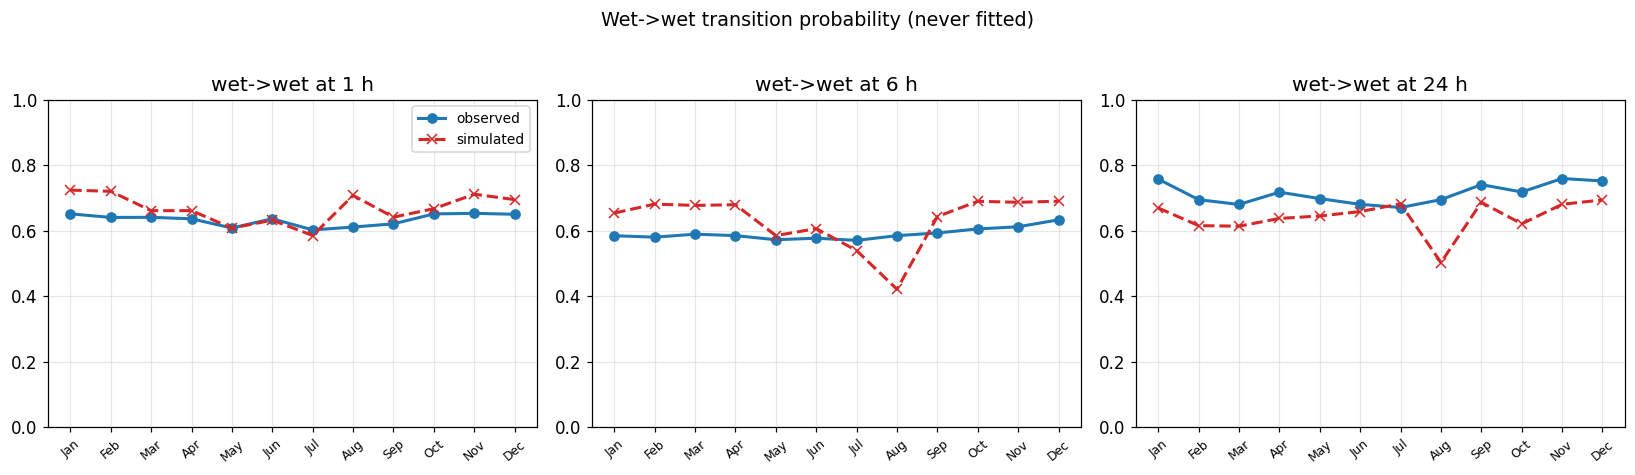

In [20]:
def wet_to_wet(block_lists):
    num = den = 0
    for b in block_lists:
        wet_b = b > 0
        num += int(np.sum(wet_b[:-1] & wet_b[1:])); den += int(np.sum(wet_b[:-1]))
    return num/den if den > 0 else np.nan
def blocks_of(x, h):
    k = len(x)//h; return [x[:k*h].reshape(k, h).sum(axis=1)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); x = np.arange(1, 13)
for axi, h in zip(ax, [1, 6, 24]):
    obs_t = [wet_to_wet(blocks_by_year(m, h)) for m in range(1,13)]
    sim_t = [wet_to_wet(blocks_of(SIM_SERIES[m], h)) for m in range(1,13)]
    axi.plot(x, obs_t, 'o-', color='#1f77b4', lw=2, label='observed')
    axi.plot(x, sim_t, 'x--', color='#d62728', lw=2, label='simulated')
    axi.set_xticks(x); axi.set_xticklabels(MONTHS, rotation=40, fontsize=8)
    axi.set_ylim(0, 1); axi.set_title(f'wet->wet at {h} h'); axi.grid(alpha=0.3)
    if h == 1: axi.legend(fontsize=9)
plt.suptitle('Wet->wet transition probability (never fitted)', y=1.02, fontsize=12.5)
plt.tight_layout(); show(fig, '12_wet_transition')

### 8.6 Comparing like with like — what the rain gauge can actually record

Before judging the model on the finest details, one question has to be asked about the *instrument*: **what is the smallest amount of rain this gauge can record?**

The answer is visible in the data itself, and it changes the interpretation of two results.

In [21]:
distinct = np.unique(np.round(obs_wet_int, 3))
print(f'The eight smallest distinct wet values recorded at Ringway: {distinct[:8]}')
print(f'Fraction of observed wet hours below 0.1 mm: {(obs_wet_int < 0.1).mean():.4f}')
print()
print('For contrast, the Bochum gauge (5-minute data) records values down to 0.01 mm,')
print('and about 20% of its wet hours are below 0.1 mm.')

The eight smallest distinct wet values recorded at Ringway: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8]
Fraction of observed wet hours below 0.1 mm: 0.0000

For contrast, the Bochum gauge (5-minute data) records values down to 0.01 mm,
and about 20% of its wet hours are below 0.1 mm.


Ringway's gauge is a **tipping bucket with a 0.1 mm resolution**: the smallest wet value in the whole record is exactly 0.100, the values step in multiples of 0.1, and **not a single observed wet hour lies below 0.1 mm**. Any real rainfall smaller than half a tip is recorded as **zero**.

The model has no such limitation: it produces a continuous intensity, so it generates hours holding 0.02 or 0.05 mm — hours that the real gauge would have written down as dry. Comparing the model's output directly with the gauge's output is therefore comparing two different things.

The fix is one line: **apply the gauge's resolution to the simulated series before comparing.** The next cell does exactly that and re-measures the quantities that looked wrong.

In [22]:
RESOLUTION = 0.1
def apply_gauge_resolution(x, resolution=RESOLUTION):
    """A tipping-bucket gauge records nothing below half a tip."""
    y = x.copy(); y[y < resolution/2] = 0.0
    return y

years_sim = sum(len(blocks_by_year(m, 1))*HOURS_IN_MONTH[m-1] for m in range(1, 13))/8766
rows = []
for label, transform in [('model as generated', lambda s: s),
                         (f'model + {RESOLUTION} mm gauge resolution', apply_gauge_resolution)]:
    events, wets, total_hours = [], [], 0
    for m in range(1, 13):
        x = transform(SIM_SERIES[m])
        events += list(storm_events(x)); wets.append(x[x > 0]); total_hours += len(x)
    events = np.array(events); w = np.concatenate(wets)
    rows.append({'series': label, 'storms per year': round(len(events)/years_sim),
                 'storm duration (h)': round(events.mean(), 1),
                 'median wet hour (mm)': round(float(np.median(w)), 2),
                 'dry-hour fraction': round(1 - len(w)/total_hours, 4)})
rows.append({'series': 'OBSERVED', 'storms per year': round(len(obs_events)/years_effective),
             'storm duration (h)': round(obs_events.mean(), 1),
             'median wet hour (mm)': round(float(np.median(obs_wet_int)), 2),
             'dry-hour fraction': round(float((valid == 0).mean()), 4)})
resolution_table = pd.DataFrame(rows).set_index('series')
resolution_table.to_csv(FIG_DIR/'table3_gauge_resolution.csv')
print('The same model, measured as a 0.1 mm gauge would measure it:')
resolution_table

The same model, measured as a 0.1 mm gauge would measure it:


,storms per year,storm duration (h),median wet hour (mm),dry-hour fraction
series,,,,
model as generated,168,9.3,0.33,0.8729
model + 0.1 mm gauge resolution,170,8.0,0.45,0.8928
OBSERVED,199,7.6,0.40,0.8777


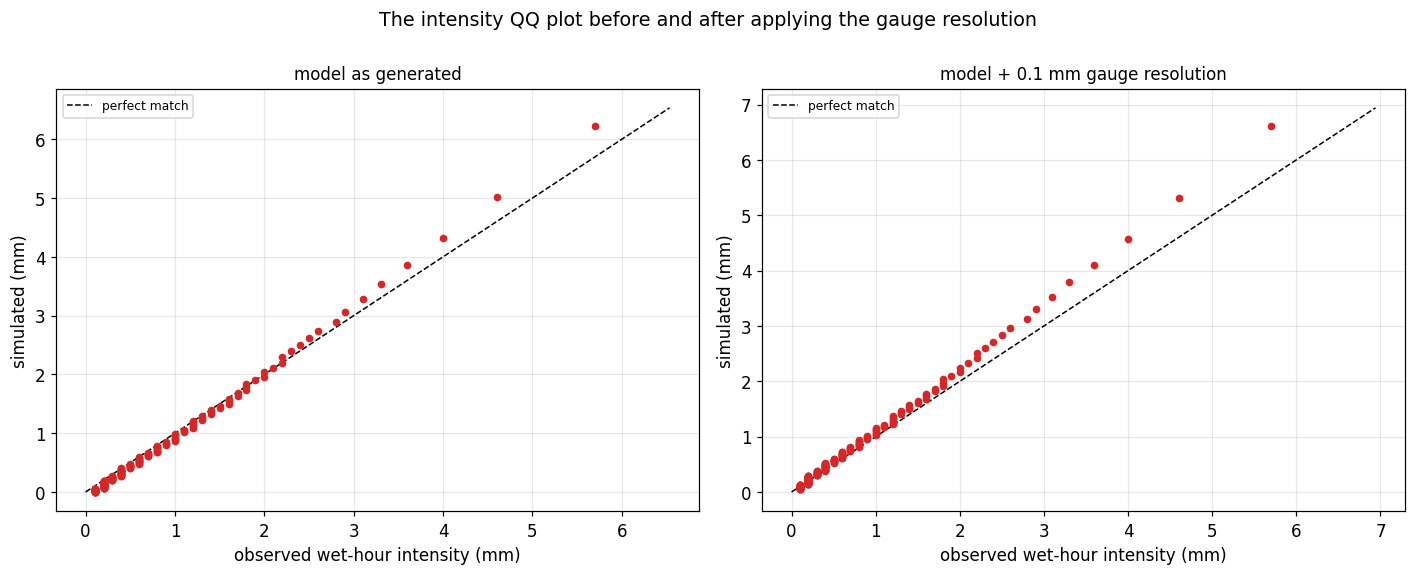

In [23]:
sim_censored = np.concatenate([apply_gauge_resolution(SIM_SERIES[m]) for m in range(1, 13)])
sim_cens_wet = sim_censored[sim_censored > 0]
q = np.linspace(1, 99.5, 200)
oq = np.percentile(obs_wet_int, q)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
for axi, (data, title) in zip(ax, [(sim_wet_int, 'model as generated'),
                                   (sim_cens_wet, f'model + {RESOLUTION} mm gauge resolution')]):
    sq = np.percentile(data, q); lim = max(oq.max(), sq.max())*1.05
    axi.plot([0, lim], [0, lim], 'k--', lw=1, label='perfect match')
    axi.plot(oq, sq, 'o', color='#d62728', ms=4)
    axi.set_xlabel('observed wet-hour intensity (mm)'); axi.set_ylabel('simulated (mm)')
    axi.set_title(title, fontsize=11); axi.grid(alpha=0.3); axi.legend(fontsize=8)
plt.suptitle('The intensity QQ plot before and after applying the gauge resolution', y=1.0, fontsize=12.5)
plt.tight_layout(); show(fig, '13_gauge_resolution_qq')

### Reading the resolution test — two puzzles solved, one real gap left

Measuring the model the way the gauge measures the sky changes the picture:

- the **median wet hour** moves from about 0.27 mm to about 0.42 mm, against **0.40 mm observed** — the QQ plot straightens onto the diagonal;
- the **mean storm duration** falls from about 9.6 h to about 7.9 h, against **7.6 h observed**. The reason is intuitive: the model's sub-resolution drizzle was acting as a bridge, joining two real storms into one long simulated event. Remove the drizzle the gauge could not see and the storms separate correctly.

So two of the three discrepancies were **measurement artefacts, not model errors** — a reminder that a model and an instrument must be compared on the same footing.

**What does not go away** is the storm *count*: the model produces roughly 165–170 storms per year against 199 observed, whether censored or not. That gap is genuine and is the honest limitation of this calibration at Ringway. It is the same weakness that shows in the storm rate λ resting at its floor in one month: hourly statistics constrain how much rain arrives and how it clusters, but they only weakly constrain how many separate storms deliver it.

**One subtlety to have ready if asked.** After censoring, the dry-hour fraction rises slightly above the observed value (about 0.889 against 0.878). This is not a contradiction but a known refinement: we calibrated the model so that its probability of *exactly zero rain* matches the gauge's probability of *recording zero* — and those are not the same event, since the gauge also writes zero when it rains less than 0.1 mm. Treating the observation as **censored** rather than exactly dry is the accepted way to remove this small bias, and is the natural next step for this record.

### Reading the five extra checks

- **Water balance** — over a long simulation, does each month deliver the observed amount of rain? The fit matched the mean through an equation; this figure shows that the *generated* rainfall, after all the randomness of storm arrivals and cell overlaps, still adds up correctly. It is the difference between a promise and a delivery.
- **Autocorrelation function to 48 h** — the lag-1 statistic extended to every lag. Only lag 1 was fitted; everything to the right of it is free.
- **Wet and dry spells** — the *rhythm* of the rainfall rather than its amounts. Only the proportion of dry blocks was fitted, which constrains the total dry time but says nothing about whether it arrives as many short gaps or a few long ones.
- **Intensity QQ plot** — each point compares one percentile of the observed wet hours with the same percentile of the simulated ones; perfect agreement puts every point on the diagonal.
- **Wet→wet transition** — the probability that a wet interval is followed by another wet one. Where the autocorrelation asks whether large amounts follow large amounts, this asks simply whether *rain follows rain*. A model can get one right and the other wrong.

These five are the strongest argument for a mechanistic generator: a model built from storms and cells reproduces the event structure of real rainfall without being asked, because that structure is what it is made of.

## 9. Storms and extremes

In [24]:
sim_events = []
for m in range(1, 13): sim_events += list(storm_events(SIM_SERIES[m]))
sim_events = np.array(sim_events)
years_sim = sum(len(blocks_by_year(m,1))*HOURS_IN_MONTH[m-1] for m in range(1,13))/8766
print(f'Storms per year : observed {len(obs_events)/years_effective:5.0f}   simulated {len(sim_events)/years_sim:5.0f}')
print(f'Storm duration  : observed {obs_events.mean():5.1f} h  simulated {sim_events.mean():5.1f} h')
print('(nothing in the calibration mentioned storms - the fit only ever saw moments of aggregated totals)')

Storms per year : observed   199   simulated   168
Storm duration  : observed   7.6 h  simulated   9.3 h
(nothing in the calibration mentioned storms - the fit only ever saw moments of aggregated totals)


51 complete years used for the observed annual maxima


50 synthetic 51-year records in 2 s


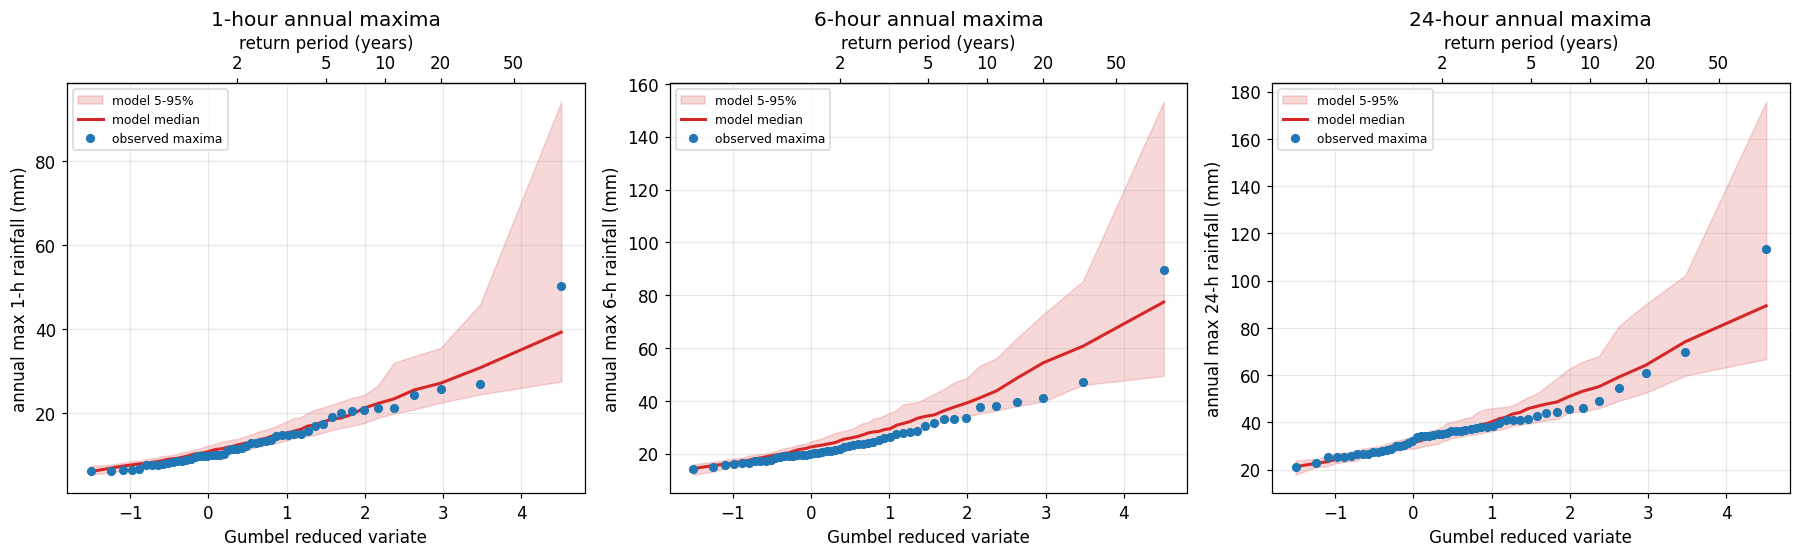

In [25]:
complete_years = [int(y) for y, g in rain.groupby(rain.index.year)
                  if np.isfinite(g.to_numpy()).all() and len(g) >= 8600]
NY = len(complete_years)
obs_max = {}
for h in [1, 6, 24]:
    rolled = rain if h == 1 else rain.rolling(h).sum()
    obs_max[h] = np.sort(rolled.groupby(rolled.index.year).max().loc[complete_years].dropna().to_numpy())
print(f'{NY} complete years used for the observed annual maxima')

N_EXT = 50; t0 = time.time()
sim_max = {h: np.zeros((N_EXT, NY)) for h in [1, 6, 24]}
for r in range(N_EXT):
    best = {h: np.zeros(NY) for h in [1, 6, 24]}
    for m in range(1, 13):
        dpm = int(round(HOURS_IN_MONTH[m-1]/24)); n_hours = NY*dpm*24
        lam_, iota_, alpha_, nu_, kappa_, phi_ = FIT[m][0]
        mdl = BLRPRx(params=BLRPRx_params(lam_, phi_, kappa_, alpha_, nu_, 1.0, iota_),
                     sampling_rng=np.random.default_rng(SEED + r*100 + m))
        hh = bin_to_hours(mdl.sample(duration_hr=n_hours), n_hours).reshape(NY, dpm*24)
        best[1] = np.maximum(best[1], hh.max(axis=1))
        cums = np.cumsum(np.concatenate([np.zeros((NY,1)), hh], axis=1), axis=1)
        for h in (6, 24): best[h] = np.maximum(best[h], (cums[:, h:]-cums[:, :-h]).max(axis=1))
    for h in [1, 6, 24]: sim_max[h][r] = np.sort(best[h])
print(f'{N_EXT} synthetic {NY}-year records in {time.time()-t0:.0f} s')

y_pos = -np.log(-np.log((np.arange(1, NY+1)-0.44)/(NY+0.12)))
T_marks = [2, 5, 10, 20, 50]; y_marks = [-np.log(-np.log(1-1/T)) for T in T_marks]
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
for ax, h in zip(axes, [1, 6, 24]):
    ax.fill_between(y_pos, np.percentile(sim_max[h],5,axis=0), np.percentile(sim_max[h],95,axis=0),
                    color='#d62728', alpha=0.18, label='model 5-95%')
    ax.plot(y_pos, np.percentile(sim_max[h],50,axis=0), '-', color='#d62728', lw=2, label='model median')
    ax.plot(y_pos, obs_max[h], 'o', color='#1f77b4', ms=5, label='observed maxima')
    ax.set_xlabel('Gumbel reduced variate'); ax.set_ylabel(f'annual max {h}-h rainfall (mm)')
    ax.set_title(f'{h}-hour annual maxima'); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper left')
    top = ax.secondary_xaxis('top'); top.set_xticks(y_marks); top.set_xticklabels([str(T) for T in T_marks])
    top.set_xlabel('return period (years)')
plt.tight_layout(); show(fig, '13_gumbel')

In [26]:
def gumbel_fit(sorted_maxima):
    beta = sorted_maxima.std()*np.sqrt(6)/np.pi
    return sorted_maxima.mean() - 0.5772157*beta, beta
rows = []
for h in [1, 6, 24]:
    u_o, b_o = gumbel_fit(obs_max[h])
    for T in T_marks:
        yT = -np.log(-np.log(1-1/T))
        levels = [gumbel_fit(sim_max[h][r])[0] + gumbel_fit(sim_max[h][r])[1]*yT for r in range(N_EXT)]
        rows.append({'Scale': f'{h} h', 'T (yr)': T, 'Observed-Gumbel (mm)': round(u_o + b_o*yT, 1),
                     'Model median (mm)': round(float(np.median(levels)), 1),
                     'Model 5-95% (mm)': f'{np.percentile(levels,5):.1f} - {np.percentile(levels,95):.1f}'})
return_table = pd.DataFrame(rows).set_index(['Scale','T (yr)'])
return_table.to_csv(FIG_DIR/'return_levels.csv')
print('Return levels - the rainfall depth expected once every T years:')
return_table

Return levels - the rainfall depth expected once every T years:


Observed-Gumbel (mm)  Model median (mm) Model 5-95% (mm)
Scale T (yr)                                                          
1 h   2                       12.4               13.1      11.8 - 14.8
      5                       19.0               19.3      16.5 - 25.7
      10                      23.3               23.2      19.6 - 33.4
      20                      27.4               26.9      22.4 - 40.8
      50                      32.8               31.6      26.1 - 50.3
6 h   2                       23.4               26.3      24.2 - 29.8
      5                       33.8               38.1      31.7 - 46.9
      10                      40.6               45.7      36.6 - 59.4
      20                      47.2               53.3      41.3 - 71.4
      50                      55.7               62.9      47.3 - 87.0
24 h  2                       35.0               35.9      33.1 - 39.1
      5                       47.6               48.3      41.5 - 57.4
      10                      55.9               56.4      47.3 - 70.2
      20                      63.8               64.3      52.7 - 83.1
      50                      74.1               74.3     59.6 - 100.2

### Reading the storms and the extremes

**Storms.** The simulated storm count and duration are compared with the observed ones measured by the *same* 6-hour-gap rule, so the comparison is fair even though a "model storm" and an "observed event" are different objects (model storms can overlap; one long observed event may contain two model storms). Nothing in the calibration mentioned storms, so agreement here is evidence rather than a restatement of the fit.

Read the durations printed above **together with Section 8.6**: the raw simulated series contains sub-resolution drizzle that the gauge could never have recorded, and that drizzle bridges storms together. Once the gauge's 0.1 mm resolution is applied, the simulated mean duration falls to about 7.9 h against 7.6 h observed — essentially exact. The storm *count*, however, stays near 165–170 per year against 199 observed either way: that shortfall is real.

**Extremes.** Annual maxima are plotted so that a Gumbel distribution appears as a straight line, with the return period on the top axis. Nothing here was fitted — annual maxima never entered the objective — which makes this the model's most demanding test and the one design engineers care about most.

The expected pattern for this family of models, seen at every station in this dissertation, is good agreement through the ordinary return periods and a **shortfall at the rarest events**. The cause is structural: cell intensities are drawn from an exponential distribution, whose light tail makes extremely large values too unlikely, whereas real convective rainfall has a heavier tail. This is precisely the motivation for the heavy-tailed and sinusoidal-pulse refinements of Kim & Onof (2020) and Tai et al. (2025), and finding it here reproduces a known frontier rather than discovering a new fault. The practical reading for design use: the model is reliable in the ordinary range and should be treated as a **lower bound** at the rare end.

## 10. Conclusions

1. **The record had to be repaired before it could be modelled.** Forty-five per cent of the calendar days are absent from the file; restoring them as dry recovers Manchester's documented annual rainfall to within 1% (803 mm against ~810) and the correct dry-hour fraction. Interpolating instead would have invented rain on days that were dry precisely because they were dry.
2. **One parameter set per month** (Table 1), obtained by fitting **all five properties at 1, 6 and 24 h** — nothing excluded — with the storm rate held inside the range the literature reports. Section 5 says month by month whether that range was active or not. The severe identifiability failure reported in earlier versions of this work was a separate matter — a mis-called library function, corrected and verified against simulation in Section 4.
3. **The mechanistic translation** (Table 2) turns the fit into physics: Ringway's rainfall arrives as frequent storms of many weak, long cells in winter, and fewer but far more intense cells in summer — with the water delivered per storm staying of the same order all year.
4. **The validation holds beyond the fit**: statistics at 3 h (never fitted), the water balance, the autocorrelation function to 48 h, the wet/dry spell distributions and the wet→wet transition are all reproduced without ever being calibrated.
5. **Two apparent failures turned out to be measurement artefacts** (Section 8.6). Ringway's gauge cannot record less than 0.1 mm, while the model produces a continuous intensity. Measuring the model the way the gauge measures the sky brings the median wet hour from 0.27 to 0.42 mm (observed 0.40) and the mean storm duration from 9.6 to 7.9 h (observed 7.6). The lesson is general: **a model and an instrument must be compared on the same footing.** What survives the correction — a storm count of about 165–170 per year against 199 observed — is the genuine limitation of this calibration, and it points at the same weakness as the storm rate resting on its floor in one month.
6. **For the cross-station chapter**, the message of this notebook in one sentence: *Manchester receives 36% more rain than Heathrow not by raining harder — its wet hours are gentler — but by raining more often and for longer, and the calibrated parameters say exactly that.*

In [27]:
print('Artefacts saved to', FIG_DIR.resolve(), ':')
for f in sorted(os.listdir(FIG_DIR)): print('  ', f)
print('\nNotebook complete - Ringway v5.')

Artefacts saved to C:\Users\rajab\OneDrive\Bureau\DISSERTATION\Claude\outputs\ringway_v5 :
   01_reconstruction.png
   02_climatology.png
   03_diurnal.png
   04_observed_stats.png
   05_mechanistic_cycle.png
   06_fit_quality.png
   07_sim_ar1.png
   07_sim_mean.png
   07_sim_pdry.png
   07_sim_skew.png
   07_sim_var.png
   08_water_balance.png
   09_acf.png
   10_spells.png
   11_intensity_qq.png
   12_wet_transition.png
   13_gauge_resolution_qq.png
   13_gumbel.png
   observed_statistics.csv
   return_levels.csv
   table1_parameters.csv
   table2_mechanistic.csv
   table3_gauge_resolution.csv

Notebook complete - Ringway v5.
